# CS6220: Homework 2 Mihir Mathur 002535005

## Answer  2: Linear Regression Pseudocode 

## Linear Regression Pseudocode

The linear regression model is implemented from scratch using NumPy matrix operations, without an existing linear regression library.

### A. Training — fit(training_dataset)

```text
FUNCTION fit(training_dataset):

    1. Separate the input features (X) and target values (Y).

    2. Add a column of ones to X for the intercept.

    3. Compute the transpose of X:
       X_T = transpose(X)

    4. Multiply the transposed matrix by X:
       X_TX = X_T × X

    5. Calculate the inverse:
       X_TX_inv = inverse(X_TX)

    6. Multiply the transposed matrix by Y:
       X_TY = X_T × Y

    7. Calculate the regression coefficients:
       beta = X_TX_inv × X_TY

    8. Return beta.

END FUNCTION
```

### B. Prediction — predict(weights, test_dataset)

```text
FUNCTION predict(weights, test_dataset):

    1. Extract the input features (X_test).

    2. Add a column of ones to X_test for the intercept.

    3. Calculate predicted values:
       Y_pred = X_test × weights

    4. Return Y_pred.

END FUNCTION
```

### C. Evaluation — evaluate_model(predictions, true_outputs)

```text
FUNCTION evaluate_model(predictions, true_outputs):

    1. Calculate prediction errors:
       errors = true_outputs - predictions

    2. Square each prediction error:
       squared_errors = errors ** 2

    3. Calculate the mean squared error:
       mse = mean(squared_errors)

    4. Calculate the root mean squared error:
       rmse = square_root(mse)

    5. Return rmse.

END FUNCTION
```
The training function calculates the regression coefficients using the normal equation. The prediction function uses these coefficients to generate predictions, and the evaluation function measures prediction error using RMSE.

### Step 1: Preparing the feature matrix X and target vector Y

In [1]:
import numpy as np

data = np.array([
    [0.2, 1.4],
    [0.5, 2.0],
    [0.8, 2.6]
])

X = data[:, :-1]   # Input features
Y = data[:, -1]    # Target values

X = np.column_stack((np.ones(X.shape[0]), X))

print("X:\n", X)
print("Y:\n", Y)

X:
 [[1.  0.2]
 [1.  0.5]
 [1.  0.8]]
Y:
 [1.4 2.  2.6]


### Step 2: Compute the weight vector β

In [2]:
# Step 2: Calculate the weight vector using the Normal Equation

X_T = X.T                     # Transpose of X
X_TX = X_T @ X                # Matrix multiplication X^T X
X_TX_inv = np.linalg.inv(X_TX) # Inverse of X^T X
X_TY = X_T @ Y                # Matrix multiplication X^T Y

beta = X_TX_inv @ X_TY        # Calculate regression coefficients

print("Weight Vector (Beta):", beta)

Weight Vector (Beta): [1. 2.]


### Step 3: Implement the fit() function

In [3]:
def fit(training_dataset):
    # Step 1: Separate input features and target values
    X = training_dataset[:, :-1]
    Y = training_dataset[:, -1]

    # Step 2: Add a column of ones for the intercept
    X = np.column_stack((np.ones(X.shape[0]), X))

    # Step 3: Compute the weight vector using the Normal Equation
    X_T = X.T
    X_TX = X_T @ X
    X_TX_inv = np.linalg.inv(X_TX)
    X_TY = X_T @ Y

    beta = X_TX_inv @ X_TY

    # Step 4: Return the weight vector
    return beta


# Test the fit function using the sample dataset
weights = fit(data)

print("Learned Weights:", weights)

Learned Weights: [1. 2.]


### Step 4: Implement the predict() function

In [4]:
def predict(weights, test_dataset):
    # Step 1: Extract input features
    X_test = test_dataset[:, :-1]

    # Step 2: Add a column of ones for the intercept
    X_test = np.column_stack((np.ones(X_test.shape[0]), X_test))

    # Step 3: Calculate predictions using the learned weights
    Y_pred = X_test @ weights

    # Step 4: Return predictions
    return Y_pred


# Test the predict function using the sample dataset
predictions = predict(weights, data)

print("Predicted Values:", predictions)
print("Actual Values:", data[:, -1])

Predicted Values: [1.4 2.  2.6]
Actual Values: [1.4 2.  2.6]


### Step 5: Implementing the evaluate_model() Function

In [5]:
def evaluate_model(predictions, true_outputs):
    # Step 1: Calculate prediction errors
    errors = true_outputs - predictions

    # Step 2: Square each prediction error
    squared_errors = errors ** 2

    # Step 3: Calculate the mean squared error
    mse = np.mean(squared_errors)

    # Step 4: Calculate root mean square error
    rmse = np.sqrt(mse)

    # Step 5: Return RMSE
    return rmse


# Test the evaluation function using sample predictions
rmse = evaluate_model(predictions, data[:, -1])

print("RMSE:", rmse)

RMSE: 5.285718846720614e-16


## Answer 3: Linear Regression Experiments

### Objective

Train, test, and evaluate the linear regression implementation developed from scratch using synthetic datasets generated with `generate_noisy_dataset()`.

### Experimental Setup

- **True functions:**
  - Linear: f(x) = 2x + 1
  - Cubic: f(x) = 0.5x³ − x² + x
- **Input range:** [0, 1]
- **Additional feature functions:** None
- **Dataset columns:** x and y
- **Dataset size:** 1,000 records per experiment
- **Noise levels:** 0.01 and 0.1, sampled uniformly from [−ε, ε]
- **Training/testing split:** 80% training (800 records) and 20% testing (200 records)
- **Random seed:** 42 for reproducibility

### Methodology

1. Generate four synthetic datasets using the two true functions and two noise levels.
2. Split each dataset into fixed training and testing sets.
3. Train the custom linear regression model using the `fit()` function.
4. Generate predictions using the `predict()` function.
5. Calculate training and testing RMSE using `evaluate_model()`.
6. For each experiment, plot the training-data scatterplot, true function, and learned linear regression model.

### Experiments

| Experiment | True Function | Noise Level |
|---|---|---|
| 1 | Linear | 0.01 |
| 2 | Linear | 0.1 |
| 3 | Cubic | 0.01 |
| 4 | Cubic | 0.1 |

### Evaluation

The models are evaluated using Root Mean Square Error (RMSE). Lower RMSE indicates better predictive accuracy.

The four experiments compare linear regression performance across different underlying functions and noise levels.

### Answer 3) Step 1: Synthetic Data Generator

In [6]:
def generate_noisy_dataset(feature_functions, true_function,
                           x_range, n_samples, epsilon, seed=42):

    # Generate uniformly distributed x-values
    rng = np.random.default_rng(seed)
    x = rng.uniform(x_range[0], x_range[1], n_samples)

    # Generate additional feature columns, if provided
    features = [x]
    for function in feature_functions:
        features.append(function(x))

    # Generate uniformly distributed noise
    noise = rng.uniform(-epsilon, epsilon, n_samples)

    # Calculate target values
    y = true_function(x) + noise

    # Combine input features and target values
    dataset = np.column_stack(features + [y])

    return dataset

### Test the data generator

In [7]:
# Define the true linear function
def linear_function(x):
    return 2 * x + 1

# Generate 1000 records without additional features
linear_data = generate_noisy_dataset(
    feature_functions=[],
    true_function=linear_function,
    x_range=(0, 1),
    n_samples=1000,
    epsilon=0.01,
    seed=42
)

print("Dataset Shape:", linear_data.shape)
print("First 5 Records:\n", linear_data[:5])

Dataset Shape: (1000, 2)
First 5 Records:
 [[0.77395605 2.53915336]
 [0.43887844 1.87692212]
 [0.85859792 2.70977644]
 [0.69736803 2.38778259]
 [0.09417735 1.19100035]]


### Step 2: Train-Test Split (80/20)

In [8]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
train_data, test_data = train_test_split(
    linear_data,
    test_size=0.2,
    random_state=42
)

# Verify dataset sizes
print("Total Records:", len(linear_data))
print("Training Records:", len(train_data))
print("Testing Records:", len(test_data))

Total Records: 1000
Training Records: 800
Testing Records: 200


### Step 3: Train, Test, and Evaluate Linear Regression

### Train, Test, and Evaluate — Experiment 1 Linear Function (Noise = 0.01)

In [9]:
# Train the linear regression model using 800 training records
weights_linear_001 = fit(train_data)

# Predict using 200 testing records
predictions_linear_001 = predict(weights_linear_001, test_data)

# Calculate training and testing RMSE
train_predictions = predict(weights_linear_001, train_data)

train_rmse = evaluate_model(
    train_predictions,
    train_data[:, -1]
)

test_rmse = evaluate_model(
    predictions_linear_001,
    test_data[:, -1]
)

# Display results
print("Experiment 1: Linear Function, Noise = 0.01")
print("Learned Weights:", weights_linear_001)
print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)

Experiment 1: Linear Function, Noise = 0.01
Learned Weights: [1.00033814 2.00009217]
Training RMSE: 0.005877410753988876
Testing RMSE: 0.005415279373381137


### Step 4: Plot Experiment 1

### Visualization — Linear Function (Noise = 0.01)

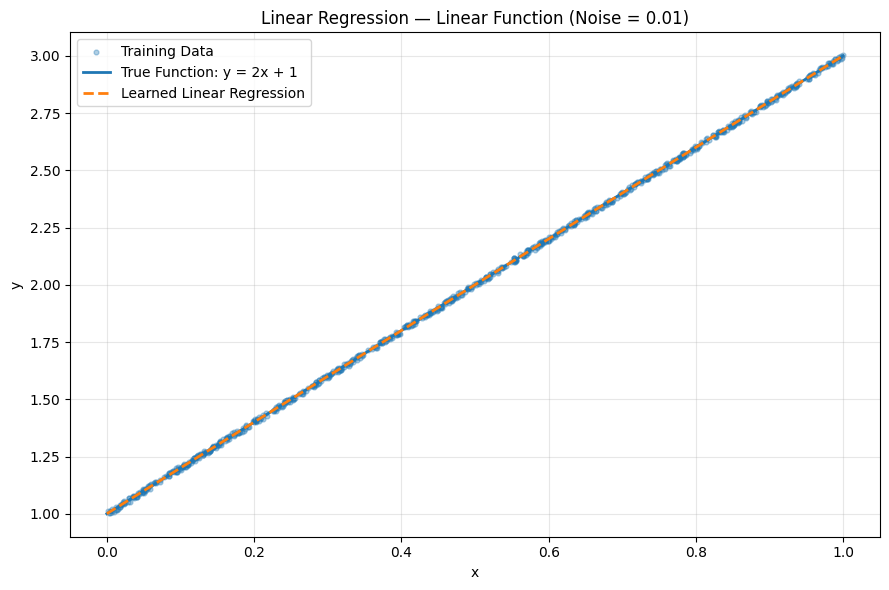

In [10]:
import matplotlib.pyplot as plt

# Generate evenly spaced x-values for smooth lines
x_plot = np.linspace(0, 1, 500)

# Calculate the true function
y_true = linear_function(x_plot)

# Calculate the learned linear regression function
y_model = weights_linear_001[0] + weights_linear_001[1] * x_plot

plt.figure(figsize=(9, 6))

# Scatterplot of training data
plt.scatter(
    train_data[:, 0],
    train_data[:, -1],
    alpha=0.35,
    s=12,
    label="Training Data"
)

# Plot the true function
plt.plot(
    x_plot, y_true,
    linewidth=2,
    label="True Function: y = 2x + 1"
)

# Plot the learned linear regression model
plt.plot(
    x_plot, y_model,
    linestyle="--",
    linewidth=2,
    label="Learned Linear Regression"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression — Linear Function (Noise = 0.01)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 5: Experiment 2 — Linear Function (Noise = 0.1)

In [11]:
# Generate dataset with higher noise
linear_data_01 = generate_noisy_dataset(
    feature_functions=[],
    true_function=linear_function,
    x_range=(0, 1),
    n_samples=1000,
    epsilon=0.1,
    seed=42
)

# Use the same fixed train-test partition
train_data_01, test_data_01 = train_test_split(
    linear_data_01,
    test_size=0.2,
    random_state=42
)

# Train the linear regression model
weights_linear_01 = fit(train_data_01)

# Predict on training and testing datasets
train_predictions_01 = predict(weights_linear_01, train_data_01)
test_predictions_01 = predict(weights_linear_01, test_data_01)

# Evaluate RMSE
train_rmse_01 = evaluate_model(
    train_predictions_01, train_data_01[:, -1]
)

test_rmse_01 = evaluate_model(
    test_predictions_01, test_data_01[:, -1]
)

print("Experiment 2: Linear Function, Noise = 0.1")
print("Learned Weights:", weights_linear_01)
print("Training RMSE:", train_rmse_01)
print("Testing RMSE:", test_rmse_01)

Experiment 2: Linear Function, Noise = 0.1
Learned Weights: [1.00338144 2.00092168]
Training RMSE: 0.058774107539888716
Testing RMSE: 0.05415279373380866


### Step 6: Visualize Experiment 2

### Visualization — Linear Function (Noise = 0.1)

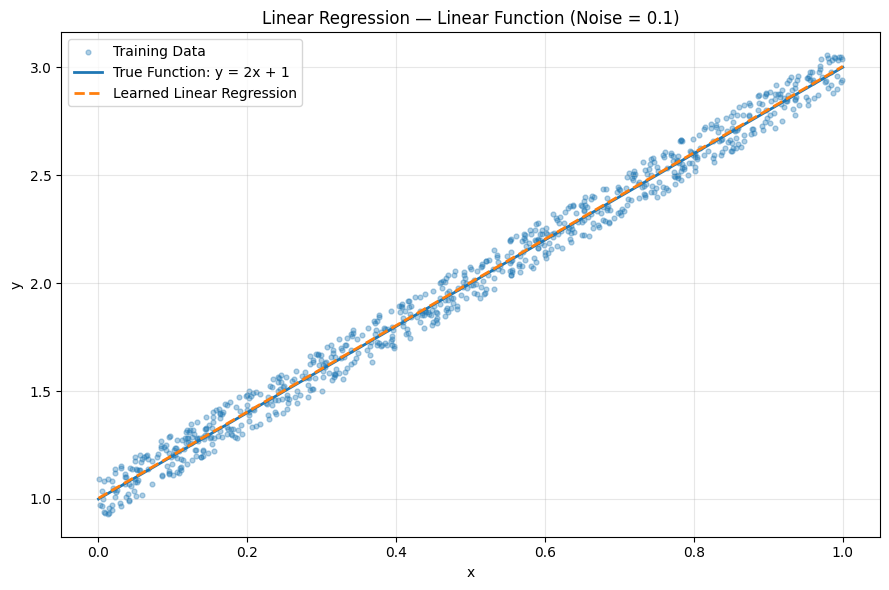

In [12]:
# Generate evenly spaced x-values
x_plot = np.linspace(0, 1, 500)

# Calculate the true function
y_true = linear_function(x_plot)

# Calculate the learned regression function
y_model_01 = (
    weights_linear_01[0]
    + weights_linear_01[1] * x_plot
)

plt.figure(figsize=(9, 6))

# Scatterplot of training data
plt.scatter(
    train_data_01[:, 0],
    train_data_01[:, -1],
    alpha=0.35,
    s=12,
    label="Training Data"
)

# Plot the true function
plt.plot(
    x_plot,
    y_true,
    linewidth=2,
    label="True Function: y = 2x + 1"
)

# Plot the learned regression model
plt.plot(
    x_plot,
    y_model_01,
    linestyle="--",
    linewidth=2,
    label="Learned Linear Regression"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression — Linear Function (Noise = 0.1)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 7: Experiment 3 — Cubic Function (Noise = 0.01)

In [13]:
# Define the true cubic function
def cubic_function(x):
    return 0.5 * x**3 - x**2 + x


# Generate 1000 records without additional features
cubic_data_001 = generate_noisy_dataset(
    feature_functions=[],
    true_function=cubic_function,
    x_range=(0, 1),
    n_samples=1000,
    epsilon=0.01,
    seed=42
)

# Split into 80% training and 20% testing
cubic_train_001, cubic_test_001 = train_test_split(
    cubic_data_001,
    test_size=0.2,
    random_state=42
)

# Train using our own linear regression implementation
weights_cubic_001 = fit(cubic_train_001)

# Generate predictions
cubic_train_pred_001 = predict(
    weights_cubic_001, cubic_train_001
)

cubic_test_pred_001 = predict(
    weights_cubic_001, cubic_test_001
)

# Calculate training and testing RMSE
cubic_train_rmse_001 = evaluate_model(
    cubic_train_pred_001,
    cubic_train_001[:, -1]
)

cubic_test_rmse_001 = evaluate_model(
    cubic_test_pred_001,
    cubic_test_001[:, -1]
)

# Display results
print("Experiment 3: Cubic Function, Noise = 0.01")
print("Dataset Shape:", cubic_data_001.shape)
print("Training Records:", len(cubic_train_001))
print("Testing Records:", len(cubic_test_001))
print("Learned Weights:", weights_cubic_001)
print("Training RMSE:", cubic_train_rmse_001)
print("Testing RMSE:", cubic_test_rmse_001)

Experiment 3: Cubic Function, Noise = 0.01
Dataset Shape: (1000, 2)
Training Records: 800
Testing Records: 200
Learned Weights: [0.06496045 0.4533094 ]
Training RMSE: 0.021657020927493074
Testing RMSE: 0.021498069432246844


### Step 8: Visualize Experiment 3

### Visualization — Cubic Function (Noise = 0.01)

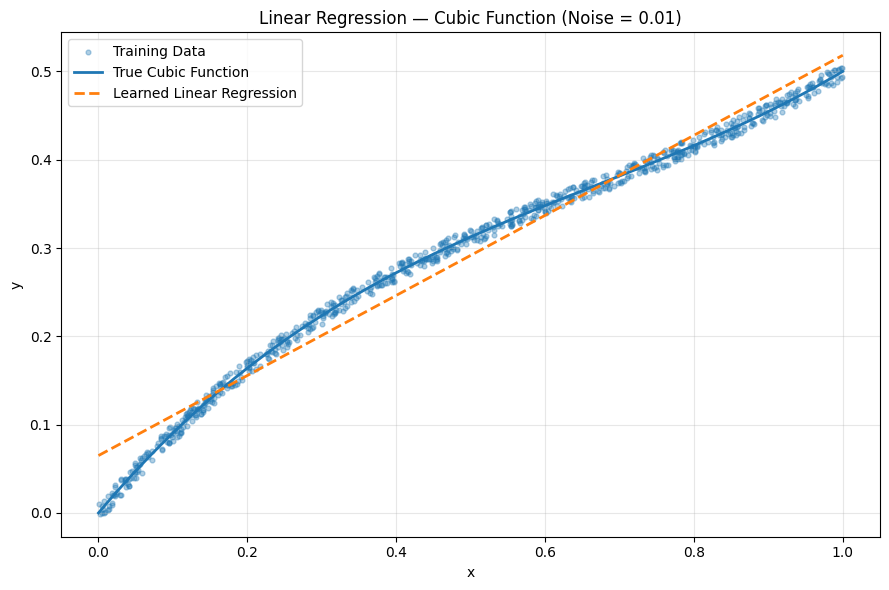

In [14]:
# Generate evenly spaced x-values for smooth curves
x_plot = np.linspace(0, 1, 500)

# Calculate the true cubic function
y_true_cubic = cubic_function(x_plot)

# Calculate the learned linear regression model
y_model_cubic_001 = (
    weights_cubic_001[0]
    + weights_cubic_001[1] * x_plot
)

plt.figure(figsize=(9, 6))

# Scatterplot of training data
plt.scatter(
    cubic_train_001[:, 0],
    cubic_train_001[:, -1],
    alpha=0.35,
    s=12,
    label="Training Data"
)

# Plot the true cubic function
plt.plot(
    x_plot,
    y_true_cubic,
    linewidth=2,
    label="True Cubic Function"
)

# Plot the learned linear regression model
plt.plot(
    x_plot,
    y_model_cubic_001,
    linestyle="--",
    linewidth=2,
    label="Learned Linear Regression"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression — Cubic Function (Noise = 0.01)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 9: Experiment 4 — Cubic Function (Noise = 0.1)

In [15]:
# Generate the cubic dataset with noise = 0.1
cubic_data_01 = generate_noisy_dataset(
    feature_functions=[],
    true_function=cubic_function,
    x_range=(0, 1),
    n_samples=1000,
    epsilon=0.1,
    seed=42
)

# Split into training and testing sets
cubic_train_01, cubic_test_01 = train_test_split(
    cubic_data_01,
    test_size=0.2,
    random_state=42
)

# Train the linear regression model
weights_cubic_01 = fit(cubic_train_01)

# Generate training and testing predictions
cubic_train_pred_01 = predict(
    weights_cubic_01, cubic_train_01
)

cubic_test_pred_01 = predict(
    weights_cubic_01, cubic_test_01
)

# Calculate training RMSE
cubic_train_rmse_01 = evaluate_model(
    cubic_train_pred_01,
    cubic_train_01[:, -1]
)

# Calculate testing RMSE
cubic_test_rmse_01 = evaluate_model(
    cubic_test_pred_01,
    cubic_test_01[:, -1]
)

# Display results
print("Experiment 4: Cubic Function, Noise = 0.1")
print("Dataset Shape:", cubic_data_01.shape)
print("Training Records:", len(cubic_train_01))
print("Testing Records:", len(cubic_test_01))
print("Learned Weights:", weights_cubic_01)
print("Training RMSE:", cubic_train_rmse_01)
print("Testing RMSE:", cubic_test_rmse_01)

Experiment 4: Cubic Function, Noise = 0.1
Dataset Shape: (1000, 2)
Training Records: 800
Testing Records: 200
Learned Weights: [0.06800375 0.45413891]
Training RMSE: 0.062318738458291154
Testing RMSE: 0.05938981758507496


### Step 10: Visualize Experiment 4

### Visualization — Cubic Function (Noise = 0.1)

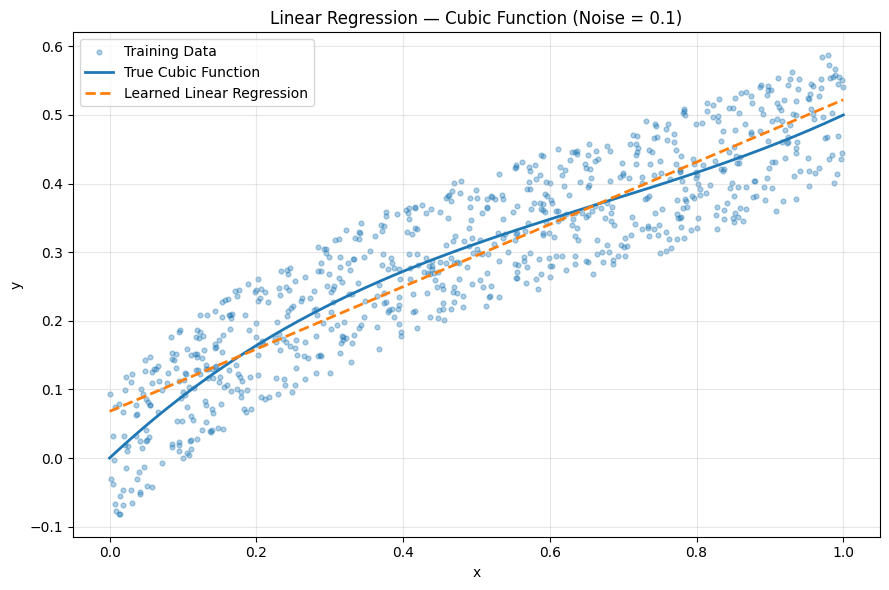

In [16]:
# Generate evenly spaced x-values
x_plot = np.linspace(0, 1, 500)

# Calculate the true cubic function
y_true_cubic = cubic_function(x_plot)

# Calculate the learned linear regression function
y_model_cubic_01 = (
    weights_cubic_01[0]
    + weights_cubic_01[1] * x_plot
)

plt.figure(figsize=(9, 6))

# Scatterplot of training data
plt.scatter(
    cubic_train_01[:, 0],
    cubic_train_01[:, -1],
    alpha=0.35,
    s=12,
    label="Training Data"
)

# Plot the true cubic function
plt.plot(
    x_plot,
    y_true_cubic,
    linewidth=2,
    label="True Cubic Function"
)

# Plot the learned linear regression model
plt.plot(
    x_plot,
    y_model_cubic_01,
    linestyle="--",
    linewidth=2,
    label="Learned Linear Regression"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression — Cubic Function (Noise = 0.1)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 11: Final Results Table

### Summary of Linear Regression Experiments

In [17]:
import pandas as pd

# Summarize all four experiments
results_ans_3 = pd.DataFrame({
    "True Function": [
        "Linear", "Linear", "Cubic", "Cubic"
    ],
    "Noise Level": [
        0.01, 0.1, 0.01, 0.1
    ],
    "Training RMSE": [
        train_rmse,
        train_rmse_01,
        cubic_train_rmse_001,
        cubic_train_rmse_01
    ],
    "Testing RMSE": [
        test_rmse,
        test_rmse_01,
        cubic_test_rmse_001,
        cubic_test_rmse_01
    ]
})

print("Answer 3: Linear Regression Results")
print(results_ans_3.round(6).to_string(index=False))

Answer 3: Linear Regression Results
True Function  Noise Level  Training RMSE  Testing RMSE
       Linear         0.01       0.005877      0.005415
       Linear         0.10       0.058774      0.054153
        Cubic         0.01       0.021657      0.021498
        Cubic         0.10       0.062319      0.059390


### Answer 3: Results and Observations

Linear regression was evaluated on four synthetic datasets using two true functions and two noise levels. Each dataset contained 1,000 records, with 80% used for training and 20% for testing.

For the linear function, the learned regression model closely matched the true function, producing low training and testing RMSE. Increasing the noise level from 0.01 to 0.1 increased the prediction error.

For the cubic function, the learned straight line could not fully capture the curvature of the true function. This resulted in higher prediction errors, even at the lower noise level. Increasing the noise further increased the RMSE.

Overall, the experiments demonstrate that linear regression performs well when the true relationship is linear, but its accuracy decreases when the underlying relationship is nonlinear or the data contains more noise.

## Answer 4: Linear Regression with Polynomial Features 

### Objective

Repeat the four linear regression experiments from Question 3 by adding two artificial features, $f_1(x) = x^2$ and $f_2(x) = x^3$, to determine whether these additional features improve model performance.

### Experimental Setup

- **True Functions:**
  - Linear: $f(x) = 2x + 1$
  - Cubic: $f(x) = 0.5x^3 - x^2 + x$
- **Input Features:** $x$, $x^2$, and $x^3$
- **Noise Levels:** $\epsilon = 0.01$ and $\epsilon = 0.1$
- **Sampling Range:** $x \in [0,1]$
- **Dataset Size:** 1,000 observations per experiment
- **Training-Testing Split:** 80% training and 20% testing
- **Random Seed:** 42 for reproducibility
- **Model:** Linear regression implemented from scratch using NumPy
- **Evaluation Metric:** Root Mean Square Error (RMSE)

### Polynomial Regression Model

The expanded linear regression model is:

$$
\hat{y} = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3
$$

Although the model includes polynomial features, it remains linear in its coefficients.

### Methodology

1. Generate synthetic datasets containing $x$, $x^2$, $x^3$, and $y$.
2. Split each dataset into 80% training and 20% testing using a fixed random seed.
3. Train the existing linear regression implementation on the expanded feature matrix.
4. Predict outputs and calculate training and testing RMSE.
5. Visualize the training data, true function, and complete learned polynomial model for all four experiments.
6. Compare the testing RMSE values from Questions 3 and 4 to determine whether the additional polynomial features improve model performance.

### Ans 4 — Step 1: Generate the expanded dataset

### Step 1: Generate Dataset with Polynomial Features (Linear Function, Noise = 0.01)

In [18]:
# Define the two artificial feature functions
def feature_x2(x):
    return x ** 2

def feature_x3(x):
    return x ** 3


# Generate dataset with x, x², x³, and y
linear_poly_data_001 = generate_noisy_dataset(
    feature_functions=[feature_x2, feature_x3],
    true_function=linear_function,
    x_range=(0, 1),
    n_samples=1000,
    epsilon=0.01,
    seed=42
)

# Verify the generated dataset
print("Dataset Shape:", linear_poly_data_001.shape)
print("First 5 Records:\n", linear_poly_data_001[:5])

Dataset Shape: (1000, 4)
First 5 Records:
 [[7.73956049e-01 5.99007965e-01 4.63605838e-01 2.53915336e+00]
 [4.38878440e-01 1.92614285e-01 8.45342568e-02 1.87692212e+00]
 [8.58597920e-01 7.37190388e-01 6.32950134e-01 2.70977644e+00]
 [6.97368029e-01 4.86322168e-01 3.39145532e-01 2.38778259e+00]
 [9.41773479e-02 8.86937286e-03 8.35294013e-04 1.19100035e+00]]


### Step 2: Train-Test Split (80/20)

### Step 2: Train-Test Split for Polynomial Features (80/20)

In [19]:
# Split expanded dataset into 80% training and 20% testing
linear_poly_train_001, linear_poly_test_001 = train_test_split(
    linear_poly_data_001,
    test_size=0.2,
    random_state=42
)

# Verify the dataset sizes
print("Total Records:", len(linear_poly_data_001))
print("Training Records:", len(linear_poly_train_001))
print("Testing Records:", len(linear_poly_test_001))

# Verify the number of columns
print("Training Dataset Shape:", linear_poly_train_001.shape)
print("Testing Dataset Shape:", linear_poly_test_001.shape)

# Verify that Q3 and Q4 use matching observations
print(
    "Same x and y values as Q3:",
    np.allclose(linear_poly_train_001[:, [0, 3]], train_data)
    and np.allclose(linear_poly_test_001[:, [0, 3]], test_data)
)

Total Records: 1000
Training Records: 800
Testing Records: 200
Training Dataset Shape: (800, 4)
Testing Dataset Shape: (200, 4)
Same x and y values as Q3: True


### Step 3: Train, Test, and Evaluate Experiment 1

### Train, Test, and Evaluate — Linear Function with Polynomial Features (Noise = 0.01)

In [20]:
# Train the model using 800 training records
weights_linear_poly_001 = fit(linear_poly_train_001)

# Predict on training and testing datasets
train_pred_linear_poly_001 = predict(
    weights_linear_poly_001,
    linear_poly_train_001
)

test_pred_linear_poly_001 = predict(
    weights_linear_poly_001,
    linear_poly_test_001
)

# Calculate training RMSE
train_rmse_linear_poly_001 = evaluate_model(
    train_pred_linear_poly_001,
    linear_poly_train_001[:, -1]
)

# Calculate testing RMSE
test_rmse_linear_poly_001 = evaluate_model(
    test_pred_linear_poly_001,
    linear_poly_test_001[:, -1]
)

# Display results
print("Experiment 1: Linear Function, Noise = 0.01")
print("Dataset Shape:", linear_poly_data_001.shape)
print("Training Records:", len(linear_poly_train_001))
print("Testing Records:", len(linear_poly_test_001))
print("Learned Weights:", weights_linear_poly_001)
print("Training RMSE:", train_rmse_linear_poly_001)
print("Testing RMSE:", test_rmse_linear_poly_001)

Experiment 1: Linear Function, Noise = 0.01
Dataset Shape: (1000, 4)
Training Records: 800
Testing Records: 200
Learned Weights: [ 0.99990183  2.00750639 -0.02189061  0.01613224]
Training RMSE: 0.0058673879433058275
Testing RMSE: 0.005431764371819783


### Step 4: Visualize Experiment 1

### Step 4: Visualization — Linear Function with Polynomial Features (Noise = 0.01)

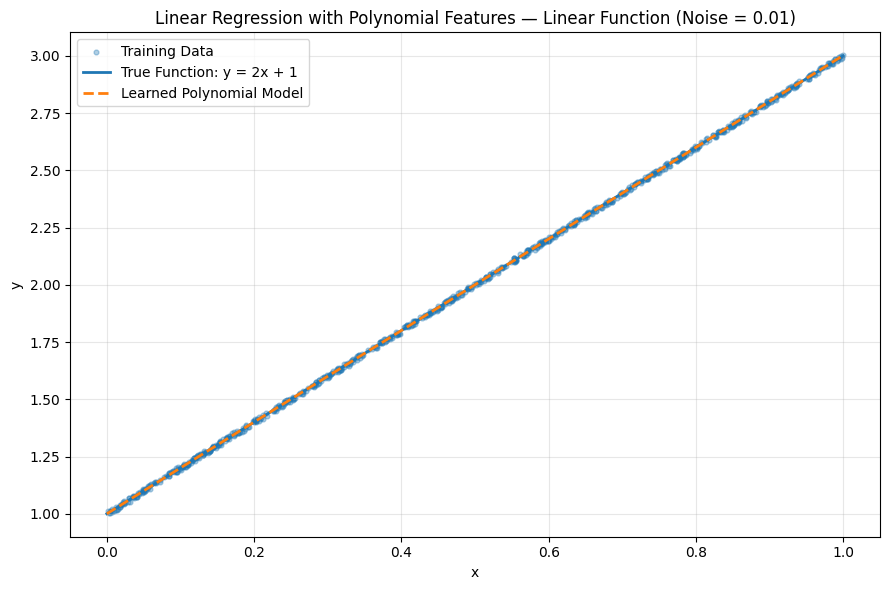

In [21]:
import matplotlib.pyplot as plt

# Generate evenly spaced x-values
x_plot = np.linspace(0, 1, 500)

# Calculate the true linear function
y_true = linear_function(x_plot)

# Calculate the entire learned polynomial function
y_model_poly_001 = (
    weights_linear_poly_001[0]
    + weights_linear_poly_001[1] * x_plot
    + weights_linear_poly_001[2] * x_plot**2
    + weights_linear_poly_001[3] * x_plot**3
)

plt.figure(figsize=(9, 6))

# Scatterplot of training data
plt.scatter(
    linear_poly_train_001[:, 0],
    linear_poly_train_001[:, -1],
    alpha=0.35,
    s=12,
    label="Training Data"
)

# Plot the true function
plt.plot(
    x_plot,
    y_true,
    linewidth=2,
    label="True Function: y = 2x + 1"
)

# Plot the complete learned polynomial model
plt.plot(
    x_plot,
    y_model_poly_001,
    linestyle="--",
    linewidth=2,
    label="Learned Polynomial Model"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(
    "Linear Regression with Polynomial Features "
    "— Linear Function (Noise = 0.01)"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 5: Experiment 2 — Linear Function (Noise = 0.1)

### Step 5: Experiment 2 — Linear Function with Polynomial Features (Noise = 0.1)

In [22]:
# Generate the dataset with polynomial features and higher noise
linear_poly_data_01 = generate_noisy_dataset(
    feature_functions=[feature_x2, feature_x3],
    true_function=linear_function,
    x_range=(0, 1),
    n_samples=1000,
    epsilon=0.1,
    seed=42
)

# Use the same fixed 80/20 partition as Q3
linear_poly_train_01, linear_poly_test_01 = train_test_split(
    linear_poly_data_01,
    test_size=0.2,
    random_state=42
)

# Train the polynomial-feature linear regression model
weights_linear_poly_01 = fit(linear_poly_train_01)

# Generate training and testing predictions
train_pred_linear_poly_01 = predict(
    weights_linear_poly_01,
    linear_poly_train_01
)

test_pred_linear_poly_01 = predict(
    weights_linear_poly_01,
    linear_poly_test_01
)

# Calculate training RMSE
train_rmse_linear_poly_01 = evaluate_model(
    train_pred_linear_poly_01,
    linear_poly_train_01[:, -1]
)

# Calculate testing RMSE
test_rmse_linear_poly_01 = evaluate_model(
    test_pred_linear_poly_01,
    linear_poly_test_01[:, -1]
)

# Display results
print("Experiment 2: Linear Function, Noise = 0.1")
print("Dataset Shape:", linear_poly_data_01.shape)
print("Training Records:", len(linear_poly_train_01))
print("Testing Records:", len(linear_poly_test_01))
print("Learned Weights:", weights_linear_poly_01)
print("Training RMSE:", train_rmse_linear_poly_01)
print("Testing RMSE:", test_rmse_linear_poly_01)

Experiment 2: Linear Function, Noise = 0.1
Dataset Shape: (1000, 4)
Training Records: 800
Testing Records: 200
Learned Weights: [ 0.99901835  2.07506392 -0.21890608  0.1613224 ]
Training RMSE: 0.05867387943305815
Testing RMSE: 0.05431764371773545


### Step 6: Visualize Experiment 2

### Step 6: Visualization — Linear Function with Polynomial Features (Noise = 0.1)

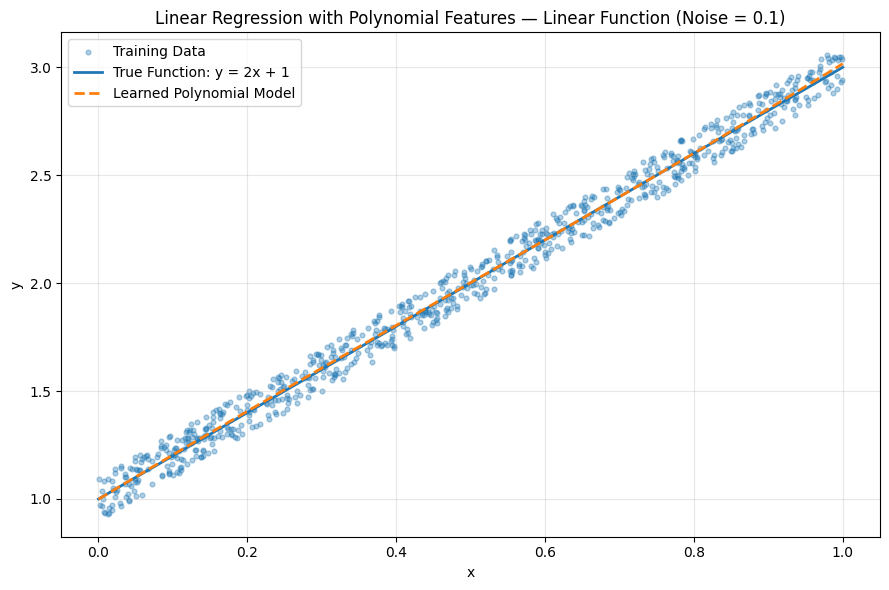

In [23]:
# Generate evenly spaced x-values for plotting
x_plot = np.linspace(0, 1, 500)

# Calculate the true linear function
y_true = linear_function(x_plot)

# Calculate the complete learned polynomial model
y_model_poly_01 = (
    weights_linear_poly_01[0]
    + weights_linear_poly_01[1] * x_plot
    + weights_linear_poly_01[2] * x_plot**2
    + weights_linear_poly_01[3] * x_plot**3
)

plt.figure(figsize=(9, 6))

# Scatterplot of the training data
plt.scatter(
    linear_poly_train_01[:, 0],
    linear_poly_train_01[:, -1],
    alpha=0.35,
    s=12,
    label="Training Data"
)

# Plot the true function
plt.plot(
    x_plot,
    y_true,
    linewidth=2,
    label="True Function: y = 2x + 1"
)

# Plot the entire learned polynomial model
plt.plot(
    x_plot,
    y_model_poly_01,
    linestyle="--",
    linewidth=2,
    label="Learned Polynomial Model"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(
    "Linear Regression with Polynomial Features "
    "— Linear Function (Noise = 0.1)"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 7: Experiment 3 — Cubic Function with Polynomial Features (Noise = 0.01)

In [24]:
# Generate the cubic dataset with polynomial features
cubic_poly_data_001 = generate_noisy_dataset(
    feature_functions=[feature_x2, feature_x3],
    true_function=cubic_function,
    x_range=(0, 1),
    n_samples=1000,
    epsilon=0.01,
    seed=42
)

# Split into 80% training and 20% testing
cubic_poly_train_001, cubic_poly_test_001 = train_test_split(
    cubic_poly_data_001,
    test_size=0.2,
    random_state=42
)

# Train the polynomial-feature linear regression model
weights_cubic_poly_001 = fit(cubic_poly_train_001)

# Generate training and testing predictions
cubic_poly_train_pred_001 = predict(
    weights_cubic_poly_001,
    cubic_poly_train_001
)

cubic_poly_test_pred_001 = predict(
    weights_cubic_poly_001,
    cubic_poly_test_001
)

# Calculate training RMSE
cubic_poly_train_rmse_001 = evaluate_model(
    cubic_poly_train_pred_001,
    cubic_poly_train_001[:, -1]
)

# Calculate testing RMSE
cubic_poly_test_rmse_001 = evaluate_model(
    cubic_poly_test_pred_001,
    cubic_poly_test_001[:, -1]
)

# Display results
print("Experiment 3: Cubic Function, Noise = 0.01")
print("Dataset Shape:", cubic_poly_data_001.shape)
print("Training Records:", len(cubic_poly_train_001))
print("Testing Records:", len(cubic_poly_test_001))
print("Learned Weights:", weights_cubic_poly_001)
print("Training RMSE:", cubic_poly_train_rmse_001)
print("Testing RMSE:", cubic_poly_test_rmse_001)

Experiment 3: Cubic Function, Noise = 0.01
Dataset Shape: (1000, 4)
Training Records: 800
Testing Records: 200
Learned Weights: [-9.81652058e-05  1.00750639e+00 -1.02189061e+00  5.16132240e-01]
Training RMSE: 0.005867387943305818
Testing RMSE: 0.0054317643717788225


### Step 8: Visualize Experiment 3

### Step 8: Visualization — Cubic Function with Polynomial Features (Noise = 0.01)

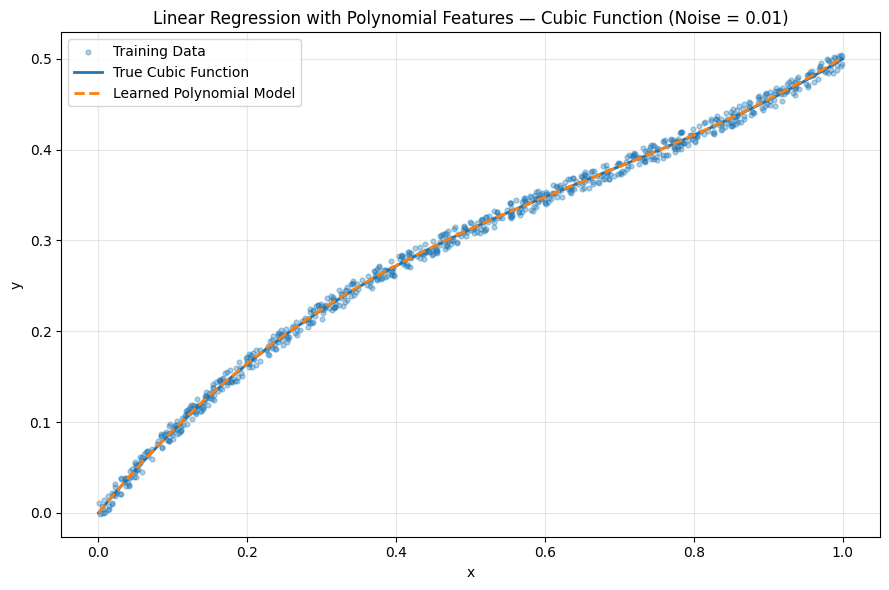

In [25]:
# Generate evenly spaced x-values for plotting
x_plot = np.linspace(0, 1, 500)

# Calculate the true cubic function
y_true_cubic = cubic_function(x_plot)

# Calculate the complete learned polynomial model
y_model_cubic_poly_001 = (
    weights_cubic_poly_001[0]
    + weights_cubic_poly_001[1] * x_plot
    + weights_cubic_poly_001[2] * x_plot**2
    + weights_cubic_poly_001[3] * x_plot**3
)

plt.figure(figsize=(9, 6))

# Scatterplot of training data
plt.scatter(
    cubic_poly_train_001[:, 0],
    cubic_poly_train_001[:, -1],
    alpha=0.35,
    s=12,
    label="Training Data"
)

# Plot the true cubic function
plt.plot(
    x_plot,
    y_true_cubic,
    linewidth=2,
    label="True Cubic Function"
)

# Plot the complete learned polynomial model
plt.plot(
    x_plot,
    y_model_cubic_poly_001,
    linestyle="--",
    linewidth=2,
    label="Learned Polynomial Model"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(
    "Linear Regression with Polynomial Features "
    "— Cubic Function (Noise = 0.01)"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 9: Experiment 4 — Cubic Function (Noise = 0.1)

### Step 9: Experiment 4 — Cubic Function with Polynomial Features (Noise = 0.1)

In [26]:
# Generate the cubic dataset with polynomial features
cubic_poly_data_01 = generate_noisy_dataset(
    feature_functions=[feature_x2, feature_x3],
    true_function=cubic_function,
    x_range=(0, 1),
    n_samples=1000,
    epsilon=0.1,
    seed=42
)

# Split into 80% training and 20% testing
cubic_poly_train_01, cubic_poly_test_01 = train_test_split(
    cubic_poly_data_01,
    test_size=0.2,
    random_state=42
)

# Train the polynomial-feature linear regression model
weights_cubic_poly_01 = fit(cubic_poly_train_01)

# Generate training and testing predictions
cubic_poly_train_pred_01 = predict(
    weights_cubic_poly_01,
    cubic_poly_train_01
)

cubic_poly_test_pred_01 = predict(
    weights_cubic_poly_01,
    cubic_poly_test_01
)

# Calculate training RMSE
cubic_poly_train_rmse_01 = evaluate_model(
    cubic_poly_train_pred_01,
    cubic_poly_train_01[:, -1]
)

# Calculate testing RMSE
cubic_poly_test_rmse_01 = evaluate_model(
    cubic_poly_test_pred_01,
    cubic_poly_test_01[:, -1]
)

# Display results
print("Experiment 4: Cubic Function, Noise = 0.1")
print("Dataset Shape:", cubic_poly_data_01.shape)
print("Training Records:", len(cubic_poly_train_01))
print("Testing Records:", len(cubic_poly_test_01))
print("Learned Weights:", weights_cubic_poly_01)
print("Training RMSE:", cubic_poly_train_rmse_01)
print("Testing RMSE:", cubic_poly_test_rmse_01)

Experiment 4: Cubic Function, Noise = 0.1
Dataset Shape: (1000, 4)
Training Records: 800
Testing Records: 200
Learned Weights: [-9.81652058e-04  1.07506392e+00 -1.21890608e+00  6.61322403e-01]
Training RMSE: 0.05867387943305815
Testing RMSE: 0.054317643717820566


### Step 10: Visualize Experiment 4

### Step 10: Visualization — Cubic Function with Polynomial Features (Noise = 0.1)

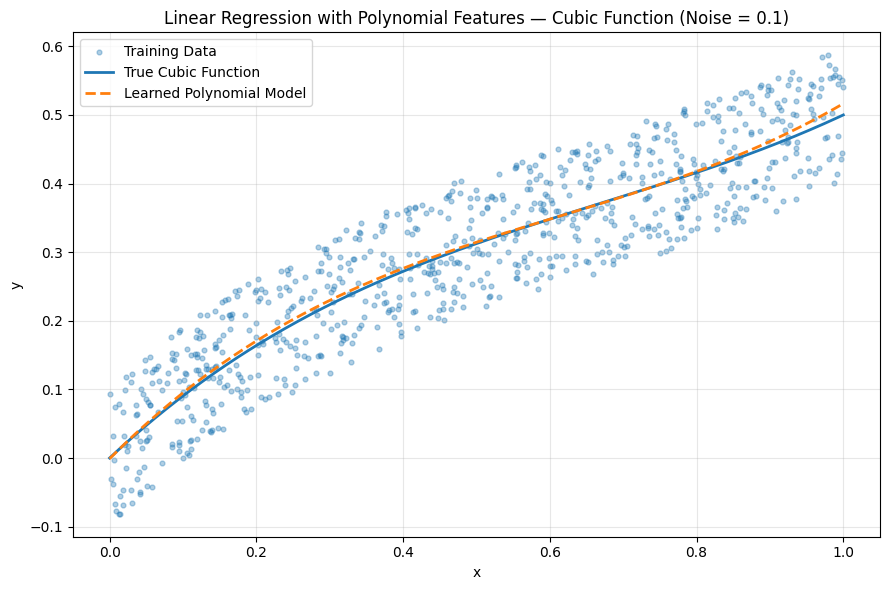

In [27]:
# Generate evenly spaced x-values
x_plot = np.linspace(0, 1, 500)

# Calculate the true cubic function
y_true_cubic = cubic_function(x_plot)

# Calculate the complete learned polynomial model
y_model_cubic_poly_01 = (
    weights_cubic_poly_01[0]
    + weights_cubic_poly_01[1] * x_plot
    + weights_cubic_poly_01[2] * x_plot**2
    + weights_cubic_poly_01[3] * x_plot**3
)

plt.figure(figsize=(9, 6))

# Scatterplot of training data
plt.scatter(
    cubic_poly_train_01[:, 0],
    cubic_poly_train_01[:, -1],
    alpha=0.35,
    s=12,
    label="Training Data"
)

# Plot the true cubic function
plt.plot(
    x_plot,
    y_true_cubic,
    linewidth=2,
    label="True Cubic Function"
)

# Plot the complete learned polynomial model
plt.plot(
    x_plot,
    y_model_cubic_poly_01,
    linestyle="--",
    linewidth=2,
    label="Learned Polynomial Model"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(
    "Linear Regression with Polynomial Features "
    "— Cubic Function (Noise = 0.1)"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 11: Comparison of Linear Regression With and Without Polynomial Features

In [28]:
import pandas as pd

# Compare testing RMSE from Q3 and Q4
comparison_q4 = pd.DataFrame({
    "True Function": [
        "Linear", "Linear", "Cubic", "Cubic"
    ],
    "Noise Level": [
        0.01, 0.1, 0.01, 0.1
    ],
    "Q3 Test RMSE": [
        test_rmse,
        test_rmse_01,
        cubic_test_rmse_001,
        cubic_test_rmse_01
    ],
    "Q4 Test RMSE": [
        test_rmse_linear_poly_001,
        test_rmse_linear_poly_01,
        cubic_poly_test_rmse_001,
        cubic_poly_test_rmse_01
    ]
})

# Calculate percentage improvement
# Positive values indicate lower testing RMSE in Q4
comparison_q4["Improvement (%)"] = (
    (comparison_q4["Q3 Test RMSE"]
     - comparison_q4["Q4 Test RMSE"])
    / comparison_q4["Q3 Test RMSE"]
) * 100

print("Ans 3 vs Ans 4: Linear Regression Comparison")
print(comparison_q4.round(6).to_string(index=False))

Ans 3 vs Ans 4: Linear Regression Comparison
True Function  Noise Level  Q3 Test RMSE  Q4 Test RMSE  Improvement (%)
       Linear         0.01      0.005415      0.005432        -0.304416
       Linear         0.10      0.054153      0.054318        -0.304416
        Cubic         0.01      0.021498      0.005432        74.733711
        Cubic         0.10      0.059390      0.054318         8.540477


### Step 12: Conclusion — Do Polynomial Features Improve Linear Regression?

Adding the polynomial features $x^2$ and $x^3$ significantly improved linear regression performance for the cubic function but not for the linear function.

For the **linear function** $f(x) = 2x + 1$, testing RMSE increased slightly by approximately **0.30%** at both noise levels, indicating no improvement from the additional features.

For the **cubic function** $f(x) = 0.5x^3 - x^2 + x$, testing RMSE decreased by approximately **74.73%** at noise level 0.01 and **8.54%** at noise level 0.1. This improvement occurred because the additional features allowed the model to represent the nonlinear cubic relationship.

**Overall, polynomial features improve linear regression when they help represent the true underlying relationship, but they do not necessarily improve performance when the original model is already appropriate.**


# Answer 5: Extrapolation Error at x = 10

### Objective

Evaluate the eight trained regression models from Questions 3 and 4 at x = 10, report their prediction errors, and determine which predictions are good.

### Experimental Setup

- **Evaluation point:** x = 10, outside the training range [0, 1].
- **True functions:**
  - Linear: f(x) = 2x + 1
  - Cubic: f(x) = 0.5x³ − x² + x
- **True outputs:**
  - Linear: f(10) = 21
  - Cubic: f(10) = 410
- **Noise levels:** 0.01 and 0.1.
- **Original model (Q3):** Uses x as the only input feature.
- **Polynomial model (Q4):** Uses x, x², and x³ as input features.
- **Evaluation metric:** Absolute Error = |True Value − Predicted Value|.

### Methodology

1. Reuse the eight previously trained models from Q3 and Q4 without retraining.
2. Generate the appropriate input features at x = 10.
3. Predict the output using each trained model.
4. Calculate the absolute error against the corresponding true function value.
5. Compare all eight results to determine which models extrapolate accurately.

**Note:** This experiment evaluates extrapolation because x = 10 lies outside the training interval [0, 1].


### Answer 5: Extrapolation Error at x = 10

### Evaluate the eight previously trained linear regression models at x = 10, compare their predictions with the true function values, and determine which models extrapolate accurately beyond the training interval [0, 1].

In [29]:

import numpy as np

# Question 5: True output values at x = 10
x_new = 10

true_linear_y = linear_function(x_new)
true_cubic_y = cubic_function(x_new)

print("Linear function: f(10) =", true_linear_y)
print("Cubic function: f(10) =", true_cubic_y)

# Create one input record for each feature schema
# Last column is the true output, as expected by predict()
linear_input = np.array([[10, true_linear_y]])

polynomial_input_linear = np.array([
    [10, 10**2, 10**3, true_linear_y]
])

polynomial_input_cubic = np.array([
    [10, 10**2, 10**3, true_cubic_y]
])

print("Original schema:", linear_input.shape)
print("Polynomial schema:", polynomial_input_linear.shape)


Linear function: f(10) = 21
Cubic function: f(10) = 410.0
Original schema: (1, 2)
Polynomial schema: (1, 4)


### Step 2: Calculate predictions and errors for all 8 combinations

In [30]:

import pandas as pd

# Reuse the trained weights from Questions 3 and 4
experiments_q5 = [
    ("Linear", 0.01, "Original", weights_linear_001),
    ("Linear", 0.01, "Polynomial", weights_linear_poly_001),
    ("Linear", 0.1, "Original", weights_linear_01),
    ("Linear", 0.1, "Polynomial", weights_linear_poly_01),
    ("Cubic", 0.01, "Original", weights_cubic_001),
    ("Cubic", 0.01, "Polynomial", weights_cubic_poly_001),
    ("Cubic", 0.1, "Original", weights_cubic_01),
    ("Cubic", 0.1, "Polynomial", weights_cubic_poly_01)
]

results_q5 = []

for function_name, noise, schema, weights in experiments_q5:

    # Select the correct true value and input schema
    if function_name == "Linear":
        true_y = true_linear_y
    else:
        true_y = true_cubic_y

    if schema == "Original":
        input_data = np.array([[x_new, true_y]])
    elif function_name == "Linear":
        input_data = polynomial_input_linear
    else:
        input_data = polynomial_input_cubic

    # Predict using the previously trained model
    predicted_y = float(predict(weights, input_data)[0])

    # Calculate absolute prediction error
    absolute_error = abs(true_y - predicted_y)

    results_q5.append({
        "True Function": function_name,
        "Noise": noise,
        "Schema": schema,
        "True y": true_y,
        "Predicted y": predicted_y,
        "Absolute Error": absolute_error
    })

# Display all eight results
results_q5_df = pd.DataFrame(results_q5)

print("Answer 5: Extrapolation Results at x = 10")
print(results_q5_df.round(6).to_string(index=False))


Answer 5: Extrapolation Results at x = 10
True Function  Noise     Schema  True y  Predicted y  Absolute Error
       Linear   0.01   Original    21.0    21.001260        0.001260
       Linear   0.01 Polynomial    21.0    35.018145       14.018145
       Linear   0.10   Original    21.0    21.012598        0.012598
       Linear   0.10 Polynomial    21.0   161.181452      140.181452
        Cubic   0.01   Original   410.0     4.598054      405.401946
        Cubic   0.01 Polynomial   410.0   424.018145       14.018145
        Cubic   0.10   Original   410.0     4.609393      405.390607
        Cubic   0.10 Polynomial   410.0   550.181452      140.181452


### Conclusion — Answer 5

The models were evaluated at x = 10, outside the training interval [0, 1]. The true outputs are f(10) = 21 for the linear function and f(10) = 410 for the cubic function. Absolute error was calculated as |true value − predicted value|.

For the linear function, the original model produced very accurate predictions, with absolute errors of 0.001260 and 0.012598 at noise levels 0.01 and 0.1, respectively. Adding polynomial features increased the errors to 14.018145 and 140.181452.

For the cubic function, the original model performed poorly, with errors of approximately 405.4 at both noise levels. Adding x² and x³ reduced these errors to 14.018145 and 140.181452, respectively. Although this improved predictions compared with the original model, the polynomial predictions were still inaccurate, especially at higher noise.

**Overall, the original linear model gives the best extrapolation for the linear function. The polynomial model improves extrapolation for the cubic function but does not guarantee accurate predictions far outside the training range.**


### Answer 6(a): 

The prediction performance depends on whether the model includes the features needed to represent the true function.

**1. Linear true function: f(x) = 2x + 1**

- The original linear regression model using x predicts well because the true relationship is linear.
- Adding x² and x³ does not improve the predictions and slightly increases testing RMSE.
- At noise 0.01, the original model achieves a testing RMSE of 0.005415, compared with 0.005432 for the polynomial-feature model.
- At noise 0.1, the original model achieves a testing RMSE of 0.054153, compared with 0.054318 for the polynomial-feature model.

**2. Cubic true function: f(x) = 0.5x³ − x² + x**

- The original model using only x cannot fully represent the nonlinear cubic relationship.
- Adding x² and x³ allows the regression model to represent the true cubic function.
- At noise 0.01, testing RMSE decreases from 0.021498 to 0.005432, an improvement of approximately 74.73%.
- At noise 0.1, testing RMSE decreases from 0.059390 to 0.054318, an improvement of approximately 8.54%.

**Conclusion:** The original linear model predicts the linear function well, while the polynomial-feature model predicts the cubic function well. Higher noise increases prediction error for both functions. These conclusions concern predictions within the observed input range [0, 1]; accurate extrapolation outside this range is not guaranteed.



### Answer 6(b): Optimal Model and Bias–Variance Tradeoff

**Identifying the Optimal Model**

The datasets were generated using:

$$
y = f(x) + \eta
$$

where $f(x)$ is the true function and $\eta$ is uniformly distributed random noise between $-\varepsilon$ and $+\varepsilon$.

Since the noise has mean zero, $E[\eta \mid x] = 0$, the optimal prediction function under squared-error loss is:

$$
f^*(x) = E[y \mid x] = f(x)
$$

This function minimizes the expected squared prediction error. The bias–variance tradeoff explains that a model should be sufficiently flexible to represent the true relationship without introducing unnecessary estimation variance.

**1. Linear True Function:**

$$
f(x) = 2x + 1
$$

- The optimal prediction function is $f^*(x) = 2x + 1$.
- The original linear regression model using only $x$ has the correct functional form and can represent this relationship exactly.
- The learned original model comes very close to the optimal function, achieving testing RMSE values of 0.005415 and 0.054153 at noise levels 0.01 and 0.1, respectively.
- Adding $x^2$ and $x^3$ is unnecessary for this true function and slightly increases testing RMSE in both experiments.

**2. Cubic True Function:**

$$
f(x) = 0.5x^3 - x^2 + x
$$

- The optimal prediction function is $f^*(x) = 0.5x^3 - x^2 + x$.
- The original model using only $x$ cannot represent the cubic relationship exactly, resulting in model bias.
- The polynomial-feature model includes $x$, $x^2$, and $x^3$, allowing it to represent the optimal cubic function.
- The learned polynomial model closely approximates the optimal cubic function on the test data within the observed input range [0, 1], achieving testing RMSE values of 0.005432 and 0.054318 at noise levels 0.01 and 0.1, respectively.
- These testing errors are substantially lower than those of the original model, which achieves 0.021498 and 0.059390.

**Conclusion:**

The optimal prediction function is the true underlying function because the additive noise has zero mean.

For the linear function, the original linear regression model is the appropriate model and closely approximates the optimal function.

For the cubic function, the polynomial-feature regression model is the appropriate model and closely approximates the optimal function within the observed input range.

The bias–variance tradeoff shows that the model should have enough complexity to capture the true relationship without introducing unnecessary complexity. The remaining prediction errors arise primarily from irreducible random noise and finite-sample estimation error, with additional approximation bias possible when the model cannot represent the true function.



## Answer 6(c): Irreducible Error

### Determining the Irreducible Error

The datasets were generated using:

$$
y = f(x) + \eta
$$

where the random noise is uniformly distributed:

$$
\eta \sim U(-\varepsilon, \varepsilon)
$$

Since the noise has mean zero and is independent of the input, the optimal prediction function is:

$$
f^*(x) = E[y \mid x] = f(x)
$$

Even the optimal model cannot predict the random noise. Therefore, the irreducible mean squared error is the variance of the noise:

$$
\mathrm{MSE}_{\mathrm{irreducible}} = \mathrm{Var}(\eta) = \frac{\varepsilon^2}{3}
$$

Since the regression experiments were evaluated using RMSE, the corresponding theoretical irreducible RMSE is:

$$
\mathrm{RMSE}_{\mathrm{irreducible}} = \sqrt{\frac{\varepsilon^2}{3}} = \frac{\varepsilon}{\sqrt{3}}
$$

The irreducible error depends on the noise level, not on whether the true function is linear or cubic.


In [31]:

import numpy as np
import pandas as pd

# Calculate theoretical irreducible error
noise_levels = [0.01, 0.1]

irreducible_results = []

for function_name in ["Linear", "Cubic"]:
    for epsilon in noise_levels:

        irreducible_mse = epsilon**2 / 3
        irreducible_rmse = epsilon / np.sqrt(3)

        irreducible_results.append({
            "True Function": function_name,
            "Noise Level": epsilon,
            "Irreducible MSE": irreducible_mse,
            "Irreducible RMSE": irreducible_rmse
        })

irreducible_df = pd.DataFrame(irreducible_results)

print("Answer 6(c): Theoretical Irreducible Error")
print(irreducible_df.round(6).to_string(index=False))


Answer 6(c): Theoretical Irreducible Error
True Function  Noise Level  Irreducible MSE  Irreducible RMSE
       Linear         0.01         0.000033          0.005774
       Linear         0.10         0.003333          0.057735
        Cubic         0.01         0.000033          0.005774
        Cubic         0.10         0.003333          0.057735



### Step 3: Compare Irreducible RMSE with Testing RMSE

Compare the theoretical irreducible RMSE with the testing RMSE of all eight regression models from Questions 3 and 4.

A smaller difference between testing RMSE and theoretical irreducible RMSE indicates that the model's prediction error is closer to the noise-limited theoretical benchmark.


In [32]:

# Reuse the Q3 and Q4 testing RMSE values
# and the theoretical irreducible RMSE from Step 2.

comparison_q6c = pd.DataFrame({
    "True Function": [
        "Linear", "Linear", "Linear", "Linear",
        "Cubic", "Cubic", "Cubic", "Cubic"
    ],
    "Noise Level": [
        0.01, 0.01, 0.1, 0.1,
        0.01, 0.01, 0.1, 0.1
    ],
    "Model": [
        "Original", "Polynomial",
        "Original", "Polynomial",
        "Original", "Polynomial",
        "Original", "Polynomial"
    ],
    "Test RMSE": [
        test_rmse,
        test_rmse_linear_poly_001,
        test_rmse_01,
        test_rmse_linear_poly_01,
        cubic_test_rmse_001,
        cubic_poly_test_rmse_001,
        cubic_test_rmse_01,
        cubic_poly_test_rmse_01
    ]
})

# Theoretical irreducible RMSE
comparison_q6c["Irreducible RMSE"] = (
    comparison_q6c["Noise Level"] / np.sqrt(3)
)

# Absolute distance from the theoretical benchmark
comparison_q6c["Absolute RMSE Gap"] = abs(
    comparison_q6c["Test RMSE"]
    - comparison_q6c["Irreducible RMSE"]
)

print("Answer 6(c): Testing RMSE vs Irreducible RMSE")
print(comparison_q6c.round(6).to_string(index=False))


Answer 6(c): Testing RMSE vs Irreducible RMSE
True Function  Noise Level      Model  Test RMSE  Irreducible RMSE  Absolute RMSE Gap
       Linear         0.01   Original   0.005415          0.005774           0.000358
       Linear         0.01 Polynomial   0.005432          0.005774           0.000342
       Linear         0.10   Original   0.054153          0.057735           0.003582
       Linear         0.10 Polynomial   0.054318          0.057735           0.003417
        Cubic         0.01   Original   0.021498          0.005774           0.015725
        Cubic         0.01 Polynomial   0.005432          0.005774           0.000342
        Cubic         0.10   Original   0.059390          0.057735           0.001655
        Cubic         0.10 Polynomial   0.054318          0.057735           0.003417



### Conclusion — Answer 6(c)

The irreducible error is determined by the variance of the uniformly distributed additive noise. It is independent of whether the true function is linear or cubic.

- **Noise level 0.01:** Irreducible MSE = 0.00003333 and irreducible RMSE ≈ 0.005774.
- **Noise level 0.1:** Irreducible MSE = 0.00333333 and irreducible RMSE ≈ 0.057735.

**Linear true function:** The original linear regression model performs close to the theoretical irreducible RMSE at both noise levels, with testing RMSE values of 0.005415 and 0.054153. Adding polynomial features does not improve performance.

**Cubic true function:** The polynomial-feature model performs close to the theoretical irreducible RMSE, with testing RMSE values of 0.005432 and 0.054318. At noise 0.01, the original linear model performs substantially worse, with testing RMSE of 0.021498. At noise 0.1, its testing RMSE of 0.059390 is numerically close to the irreducible RMSE, but this does not eliminate the model's inability to represent the cubic relationship.

The testing RMSE can be slightly lower than the theoretical irreducible RMSE because the theoretical value represents expected population error, whereas the reported testing RMSE is calculated using a finite test sample.

**Overall, the original linear model for the linear function and the polynomial-feature model for the cubic function achieve testing errors close to the theoretical noise-limited benchmark. The results demonstrate that selecting an appropriate model structure helps minimize avoidable prediction error, while irreducible random noise cannot be eliminated.**



### Answer 7: Training and Testing RMSE vs. Polynomial Degree

For the cubic true function $f(x)=0.5x^3-x^2+x$ with noise level $\varepsilon=0.1$, evaluate polynomial regression models with degrees 1 through 10.

Each model uses the same 1,000 observations and the same 80%/20% training/testing split. The input features are expanded incrementally from $x$ to $(x,x^2,\ldots,x^{10})$.

Compare training and testing RMSE to investigate how increasing model complexity affects prediction performance and generalization.


In [33]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the original cubic dataset from Q3/Q4 (noise = 0.1)
# Dataset columns: [x, y]
cubic_q7_data = cubic_data_01.copy()

# Reuse the same 80/20 partition
train_q7, test_q7 = train_test_split(
    cubic_q7_data,
    test_size=0.2,
    random_state=42
)

degrees_q7 = list(range(1, 11))
train_rmse_q7 = []
test_rmse_q7 = []

for degree in degrees_q7:

    # Create polynomial features x, x^2, ..., x^degree
    def add_polynomial_features(data, degree):
        x = data[:, 0]
        y = data[:, -1]

        features = np.column_stack([
            x ** power
            for power in range(1, degree + 1)
        ])

        return np.column_stack([features, y])

    train_poly = add_polynomial_features(train_q7, degree)
    test_poly = add_polynomial_features(test_q7, degree)

    # Train using the existing NumPy implementation
    weights = fit(train_poly)

    # Predict training and testing outputs
    train_predictions = predict(weights, train_poly)
    test_predictions = predict(weights, test_poly)

    # Calculate RMSE
    train_rmse = evaluate_model(
        train_predictions,
        train_poly[:, -1]
    )

    test_rmse = evaluate_model(
        test_predictions,
        test_poly[:, -1]
    )

    train_rmse_q7.append(train_rmse)
    test_rmse_q7.append(test_rmse)

# Display results
results_q7 = pd.DataFrame({
    "Polynomial Degree": degrees_q7,
    "Training RMSE": train_rmse_q7,
    "Testing RMSE": test_rmse_q7
})

print("Answer 7: RMSE vs. Polynomial Degree")
print(results_q7.round(6).to_string(index=False))


Answer 7: RMSE vs. Polynomial Degree
 Polynomial Degree  Training RMSE  Testing RMSE
                 1       0.062319      0.059390
                 2       0.059953      0.055370
                 3       0.058674      0.054318
                 4       0.058674      0.054316
                 5       0.058650      0.054262
                 6       0.058593      0.053991
                 7       0.058584      0.053970
                 8       0.058547      0.053891
                 9       0.058545      0.053842
                10       0.058536      0.053773



### Plot Training and Testing RMSE vs. Polynomial Degree

Plot the training and testing RMSE for polynomial degrees 1 through 10 using the cubic true function with noise level 0.1.

Both curves are plotted on the same graph to compare how increasing polynomial complexity affects training performance and generalization to unseen test data.


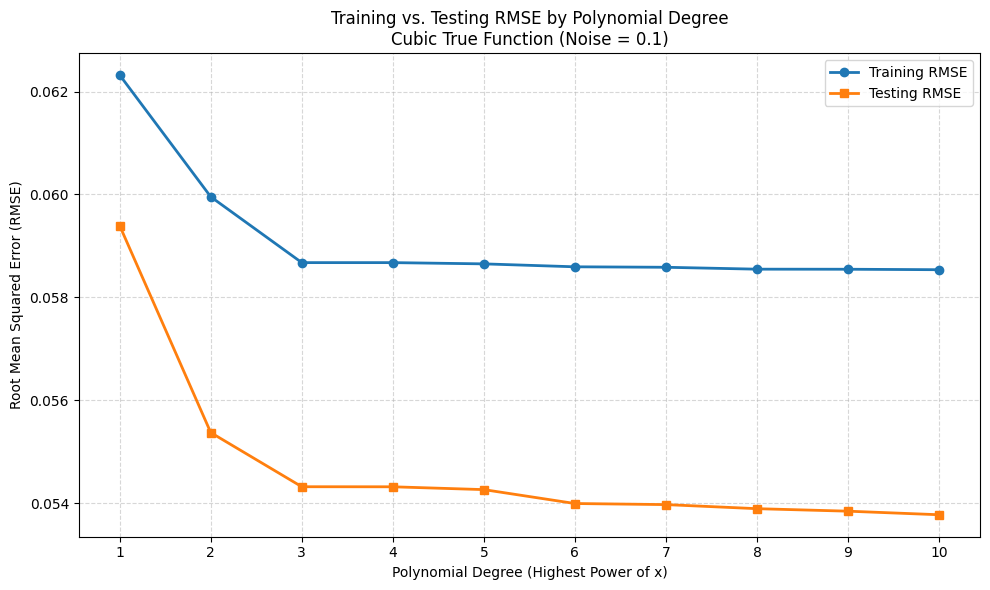

In [34]:

# Answer 7: Plot training and testing RMSE

plt.figure(figsize=(10, 6))

plt.plot(
    degrees_q7,
    train_rmse_q7,
    marker="o",
    linewidth=2,
    label="Training RMSE"
)

plt.plot(
    degrees_q7,
    test_rmse_q7,
    marker="s",
    linewidth=2,
    label="Testing RMSE"
)

plt.xlabel("Polynomial Degree (Highest Power of x)")
plt.ylabel("Root Mean Squared Error (RMSE)")

plt.title(
    "Training vs. Testing RMSE by Polynomial Degree\n"
    "Cubic True Function (Noise = 0.1)"
)

plt.xticks(range(1, 11))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()


### Interpretation — Answer 7

As polynomial degree increases from 1 to 10, training RMSE decreases from 0.062319 to 0.058536, while testing RMSE decreases overall from 0.059390 to 0.053773. The largest improvements occur up to degree 3, after which both errors change only slightly, indicating diminishing benefits from additional polynomial features and no clear evidence of overfitting within the tested degrees.


## Answer 8: Regression Tree Implementation and Pseudocode

### Objective

Implement a regression tree from scratch using recursive binary splits without an existing tree library.

The RegressionTree class will support:

1. fit(dataset, min_records): Build the regression tree.
2. predict(X): Predict outputs by traversing the tree.
3. visualize(): Display the tree's split points and piecewise-constant predictions.

### Step 1: Understanding Binary Splitting

At each node, the regression tree searches for a feature and threshold that divide the training records into two groups.

- Left child: feature value <= threshold
- Right child: feature value > threshold

For each candidate split, calculate the total squared error of the two groups, using the mean target value within each group as its prediction.

Choose the valid split with the smallest total squared error.

If the node contains fewer than min_records training records, or no valid split improves the error, create a leaf that predicts the mean target value of the records in that node.



### Step 2: Finding the Best Binary Split

For each input feature, the algorithm examines candidate thresholds between consecutive distinct sorted feature values.

For every threshold, the training records are divided into left and right groups. The mean target value of each group is used to calculate its sum of squared errors (SSE).

The best split is the feature and threshold that minimize the combined SSE of both groups.

If no valid split reduces the current node's SSE, the function returns no split.


In [35]:
import numpy as np

def find_best_split(X, y):
    best_error = float("inf")
    best_feature = None
    best_threshold = None

    n_samples, n_features = X.shape

    # Squared error before splitting
    parent_error = np.sum((y - np.mean(y)) ** 2)

    # Examine each feature
    for feature_index in range(n_features):

        unique_values = np.unique(X[:, feature_index])

        # Candidate thresholds: midpoints
        thresholds = (
            unique_values[:-1] + unique_values[1:]
        ) / 2

        for threshold in thresholds:

            # Divide records into two groups
            left_mask = X[:, feature_index] <= threshold
            right_mask = ~left_mask

            y_left = y[left_mask]
            y_right = y[right_mask]

            # Skip invalid splits
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            # Calculate squared errors
            left_error = np.sum(
                (y_left - np.mean(y_left)) ** 2
            )

            right_error = np.sum(
                (y_right - np.mean(y_right)) ** 2
            )

            total_error = left_error + right_error

            # Update the best split
            if total_error < best_error:
                best_error = total_error
                best_feature = feature_index
                best_threshold = threshold

    # Stop if splitting does not improve error
    if best_feature is None or best_error >= parent_error:
        return None, None, parent_error

    return best_feature, best_threshold, best_error


In [36]:

# Step 2C: Verify the best binary split

X_test = np.array([[1], [2], [3], [8], [9], [10]])
y_test = np.array([1, 1, 1, 10, 10, 10])

feature, threshold, error = find_best_split(X_test, y_test)

print("Best feature index:", feature)
print("Best threshold:", threshold)
print("Minimum combined SSE:", error)


Best feature index: 0
Best threshold: 5.5
Minimum combined SSE: 0.0


## Step 3: Building the Regression Tree Recursively

The regression tree is constructed recursively using the best binary split identified at each node.

1. Calculate the mean target value at the current node.
2. If the number of records is smaller than `min_records`, create a leaf node.
3. Otherwise, find the feature and threshold that minimize the combined squared error.
4. If no valid split improves the error, create a leaf node.
5. Otherwise, recursively construct the left and right subtrees.

Each leaf stores the mean target value of its training records. This produces piecewise-constant predictions.

In [37]:

# Step 3: Recursive regression tree construction

def build_tree(X, y, min_records):
    # Prediction stored at the current node
    node_prediction = float(np.mean(y))

    # Stop if the node has too few records
    if len(y) < min_records:
        return {"prediction": node_prediction}

    # Find the best binary split
    feature, threshold, error = find_best_split(X, y)

    # Stop if no split improves the error
    if feature is None:
        return {"prediction": node_prediction}

    # Partition the observations
    left_mask = X[:, feature] <= threshold
    right_mask = ~left_mask

    # Recursively build both subtrees
    left_tree = build_tree(
        X[left_mask], y[left_mask], min_records
    )

    right_tree = build_tree(
        X[right_mask], y[right_mask], min_records
    )

    # Return an internal decision node
    return {
        "feature": feature,
        "threshold": float(threshold),
        "prediction": node_prediction,
        "left": left_tree,
        "right": right_tree
    }


In [38]:

# Step 3C: Verify recursive tree construction

X_sample = np.array([[1], [2], [3], [8], [9], [10]])
y_sample = np.array([1, 1, 1, 10, 10, 10])

# Build the regression tree
sample_tree = build_tree(
    X_sample,
    y_sample,
    min_records=2
)

# Display the resulting tree
from pprint import pprint

print("Regression Tree Structure:")
pprint(sample_tree)


Regression Tree Structure:
{'feature': 0,
 'left': {'prediction': 1.0},
 'prediction': 5.5,
 'right': {'prediction': 10.0},
 'threshold': 5.5}


## Step 4: Implementing the RegressionTree Class

The `RegressionTree` class provides methods for training and making predictions using the recursive binary tree.

- **fit(dataset, min_records):** Separates the input features and target values, then constructs the regression tree recursively.
- **predict(X):** Traverses the trained tree for each input record and returns the prediction stored at the corresponding leaf.
- **visualize():** Will be implemented in the next step to display the learned tree structure and predictions.

The implementation uses the previously defined `find_best_split()` and `build_tree()` functions.

In [39]:

# Step 4: RegressionTree class

class RegressionTree:

    def __init__(self):
        self.tree = None
        self.n_features = None

    def fit(self, dataset, min_records=2):
        dataset = np.asarray(dataset, dtype=float)

        if dataset.ndim != 2 or dataset.shape[1] < 2:
            raise ValueError(
                "Dataset must contain features and a target column."
            )

        if len(dataset) == 0 or min_records < 1:
            raise ValueError("Invalid dataset or min_records.")

        # Last column contains target values
        X = dataset[:, :-1]
        y = dataset[:, -1]

        self.n_features = X.shape[1]

        # Build tree recursively
        self.tree = build_tree(X, y, min_records)

        return self

    def _predict_one(self, x, node):
        # Return prediction when a leaf is reached
        if "feature" not in node:
            return node["prediction"]

        # Traverse the appropriate branch
        if x[node["feature"]] <= node["threshold"]:
            return self._predict_one(x, node["left"])

        return self._predict_one(x, node["right"])

    def predict(self, X):
        if self.tree is None:
            raise ValueError("Train the tree before prediction.")

        X = np.asarray(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        if X.ndim != 2 or X.shape[1] != self.n_features:
            raise ValueError("Incorrect number of input features.")

        predictions = [
            self._predict_one(row, self.tree)
            for row in X
        ]

        return np.array(predictions)


In [40]:

# Step 4C: Test fit() and predict()

# Sample dataset: last column is the target y
sample_dataset = np.array([
    [1, 1],
    [2, 1],
    [3, 1],
    [8, 10],
    [9, 10],
    [10, 10]
])

# Initialize and train the regression tree
tree_model = RegressionTree()
tree_model.fit(sample_dataset, min_records=2)

# Predict on the sample input features
X_sample_test = np.array([[2], [3], [8], [9]])

predictions = tree_model.predict(X_sample_test)

print("Input values:", X_sample_test.flatten())
print("Predictions:", predictions)
print("Expected predictions:", np.array([1, 1, 10, 10]))

# Verify correctness
assert np.allclose(predictions, [1, 1, 10, 10])
print("Test passed: fit() and predict() work correctly.")


Input values: [2 3 8 9]
Predictions: [ 1.  1. 10. 10.]
Expected predictions: [ 1  1 10 10]
Test passed: fit() and predict() work correctly.



## Step 5: Visualizing the Regression Tree

The `visualize()` method will display the regression tree's learned predictions and split points.

For a dataset containing one input feature:

1. Generate evenly spaced input values across the observed range.
2. Use the trained regression tree to predict the output for each input.
3. Plot the original observations as scatter points.
4. Plot the tree's predictions as a step function.
5. Mark the learned split thresholds using vertical dashed lines.

Because each leaf predicts the mean target value of its training records, the regression tree produces piecewise-constant predictions.


In [41]:

def visualize(self, dataset, num_points=500):
    import matplotlib.pyplot as plt

    if self.tree is None:
        raise ValueError("Train the tree before visualization.")

    dataset = np.asarray(dataset, dtype=float)

    if self.n_features != 1:
        raise ValueError("Visualization supports one input feature.")

    X = dataset[:, 0]
    y = dataset[:, -1]

    # Generate evenly spaced input values
    x_grid = np.linspace(X.min(), X.max(), num_points)
    X_grid = x_grid.reshape(-1, 1)

    # Predict using the trained regression tree
    y_grid = self.predict(X_grid)

    # Collect split thresholds recursively
    def collect_thresholds(node):
        if "feature" not in node:
            return []

        thresholds = [node["threshold"]]
        thresholds += collect_thresholds(node["left"])
        thresholds += collect_thresholds(node["right"])

        return thresholds

    split_points = sorted(set(collect_thresholds(self.tree)))

    # Plot original data and tree predictions
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, alpha=0.5, label="Original Data")
    plt.step(x_grid, y_grid, where="post",
             linewidth=2, label="Regression Tree Prediction")

    for i, threshold in enumerate(split_points):
        plt.axvline(
            threshold,
            linestyle="--",
            alpha=0.5,
            label="Split Threshold" if i == 0 else None
        )

    plt.xlabel("Input Feature (x)")
    plt.ylabel("Target (y)")
    plt.title("Regression Tree: Split Points and Predictions")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


In [42]:

# Attach the visualization function to the RegressionTree class
RegressionTree.visualize = visualize

print("visualize() successfully added to RegressionTree.")


visualize() successfully added to RegressionTree.


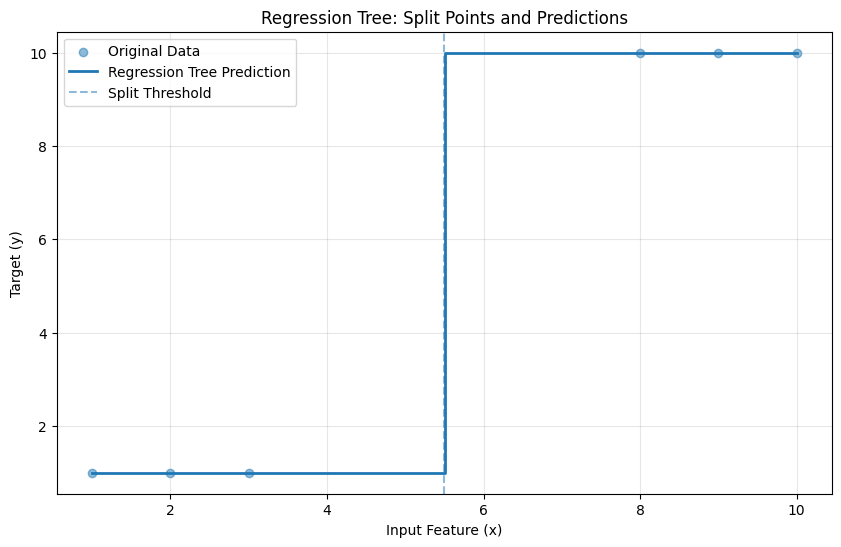

Visualization test completed.


In [43]:

# Step 5D: Verify regression tree visualization

# Reuse the sample dataset from Step 4
tree_model = RegressionTree()
tree_model.fit(sample_dataset, min_records=2)

# Display the learned regression tree
tree_model.visualize(sample_dataset)

print("Visualization test completed.")



## Step 6: Regression Tree Pseudocode

The following pseudocode summarizes the main functions used in the regression tree implementation.

### 6.1 Finding the Best Binary Split

```text
FUNCTION find_best_split(X, y):

    parent_error = SUM((y - MEAN(y))²)
    best_error = INFINITY
    best_feature = NONE
    best_threshold = NONE

    FOR each feature in X:

        values = SORT(UNIQUE(feature values))

        FOR each midpoint between consecutive values:

            left = records where feature <= midpoint
            right = records where feature > midpoint

            IF either group is empty:
                CONTINUE

            left_error = SUM((left_y - MEAN(left_y))²)
            right_error = SUM((right_y - MEAN(right_y))²)

            total_error = left_error + right_error

            IF total_error < best_error:
                best_error = total_error
                best_feature = feature
                best_threshold = midpoint

    IF best_feature is NONE OR best_error >= parent_error:
        RETURN NONE, NONE, parent_error

    RETURN best_feature, best_threshold, best_error
```

### 6.2 Recursive Tree Construction

```text
FUNCTION build_tree(X, y, min_records):

    prediction = MEAN(y)

    IF number of records < min_records:
        RETURN leaf(prediction)

    feature, threshold, error = find_best_split(X, y)

    IF feature is NONE:
        RETURN leaf(prediction)

    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold

    left_X = X[left_mask]
    left_y = y[left_mask]

    right_X = X[right_mask]
    right_y = y[right_mask]
   

    left_tree = build_tree(left_X, left_y, min_records)
    right_tree = build_tree(right_X, right_y, min_records)

    RETURN node(feature, threshold, prediction,
                left_tree, right_tree)
```



### 6.3 Training the Regression Tree: fit()

The `fit()` method validates the input dataset, separates the features from the target values, and constructs the regression tree recursively.

~~~text
FUNCTION fit(dataset, min_records):

    CONVERT dataset to numerical array

    IF dataset is not two-dimensional:
        RAISE ValueError

    IF dataset has fewer than 2 columns:
        RAISE ValueError

    IF dataset is empty OR min_records < 1:
        RAISE ValueError

    X = all columns except the last
    y = last column

    STORE number of input features

    tree = build_tree(X, y, min_records)

    STORE tree in RegressionTree object
~~~



### 6.4 Predicting with the Regression Tree: predict()

The `predict()` method generates predictions by traversing the trained regression tree. For each input record, it compares the relevant feature value with the split threshold and follows the left or right subtree until reaching a leaf node.

~~~text
FUNCTION predict_one(record, node):

    IF node is a leaf:
        RETURN node.prediction

    feature = node.feature
    threshold = node.threshold

    IF record[feature] <= threshold:
        RETURN predict_one(record, node.left)

    ELSE:
        RETURN predict_one(record, node.right)


FUNCTION predict(X):

    IF tree is not trained:
        RAISE ValueError

    CONVERT X to numerical array

    VALIDATE input feature dimensions

    predictions = empty list

    FOR each record in X:
        prediction = predict_one(record, tree)
        APPEND prediction to predictions

    RETURN predictions as numerical array
~~~



### 6.5 Visualizing the Regression Tree: visualize()

The `visualize()` method displays the regression tree's learned split thresholds and piecewise-constant predictions for a dataset with one input feature.
```text
FUNCTION collect_split_thresholds(node):

    IF node is a leaf:
        RETURN empty list

    thresholds = [node.threshold]

    thresholds += collect_split_thresholds(node.left)
    thresholds += collect_split_thresholds(node.right)

    RETURN thresholds
```

```text
FUNCTION visualize(dataset, num_points=500):

    IF tree is not trained:
        RAISE ValueError

    CONVERT dataset to numerical array

    IF number of input features != 1:
        RAISE ValueError

    X = first column of dataset
    y = last column of dataset

    x_grid = evenly spaced values from MIN(X) to MAX(X)
    X_grid = reshape x_grid into a column

    y_pred = predict(X_grid)

    PLOT original observations as scatter points

    PLOT x_grid and y_pred as a step function

    thresholds = collect_split_thresholds(tree)

    FOR each threshold in thresholds:
        DRAW vertical dashed line at threshold

    ADD title, axis labels, legend, and grid

    DISPLAY plot
```

The visualization illustrates how recursive binary splits divide the input space into regions. Each leaf predicts the mean target value of its training records, producing a piecewise-constant regression function.



# Answer 9: Regression Tree Training, Testing, and Evaluation

## Experimental Setup

The custom RegressionTree implementation from Question 8 is evaluated using the same training and testing datasets as the earlier linear regression experiments.

The experiments consider:

- True functions: Linear and Cubic
- Noise levels: ε = 0.01 and ε = 0.1
- Feature schemas: (x, y) and (x, x², x³, y)
- Minimum records for splitting: 1000, 50, and 1

A total of 24 experimental combinations are evaluated.

For each combination, the regression tree is trained and tested. Training and testing RMSE are calculated to evaluate prediction performance.

Each visualization includes the training observations, the true underlying function, and the regression tree's piecewise-constant predictions.


In [44]:

# Verify original datasets from earlier questions

dataset_names = [
    name for name in globals()
    if "linear" in name.lower() or "cubic" in name.lower()
]

for name in sorted(dataset_names):
    obj = globals()[name]

    if isinstance(obj, (pd.DataFrame, np.ndarray)):
        print(f"{name}: shape = {obj.shape}")


cubic_data_001: shape = (1000, 2)
cubic_data_01: shape = (1000, 2)
cubic_poly_data_001: shape = (1000, 4)
cubic_poly_data_01: shape = (1000, 4)
cubic_poly_test_001: shape = (200, 4)
cubic_poly_test_01: shape = (200, 4)
cubic_poly_test_pred_001: shape = (200,)
cubic_poly_test_pred_01: shape = (200,)
cubic_poly_train_001: shape = (800, 4)
cubic_poly_train_01: shape = (800, 4)
cubic_poly_train_pred_001: shape = (800,)
cubic_poly_train_pred_01: shape = (800,)
cubic_q7_data: shape = (1000, 2)
cubic_test_001: shape = (200, 2)
cubic_test_01: shape = (200, 2)
cubic_test_pred_001: shape = (200,)
cubic_test_pred_01: shape = (200,)
cubic_train_001: shape = (800, 2)
cubic_train_01: shape = (800, 2)
cubic_train_pred_001: shape = (800,)
cubic_train_pred_01: shape = (800,)
linear_data: shape = (1000, 2)
linear_data_01: shape = (1000, 2)
linear_input: shape = (1, 2)
linear_poly_data_001: shape = (1000, 4)
linear_poly_data_01: shape = (1000, 4)
linear_poly_test_001: shape = (200, 4)
linear_poly_test_01

In [45]:

# Step 3A: Check available dataset variables

for name in sorted(globals()):
    if name.startswith(("linear_", "cubic_")):
        obj = globals()[name]

        if isinstance(obj, (np.ndarray, pd.DataFrame)):
            print(f"{name}: {obj.shape}")


cubic_data_001: (1000, 2)
cubic_data_01: (1000, 2)
cubic_poly_data_001: (1000, 4)
cubic_poly_data_01: (1000, 4)
cubic_poly_test_001: (200, 4)
cubic_poly_test_01: (200, 4)
cubic_poly_test_pred_001: (200,)
cubic_poly_test_pred_01: (200,)
cubic_poly_train_001: (800, 4)
cubic_poly_train_01: (800, 4)
cubic_poly_train_pred_001: (800,)
cubic_poly_train_pred_01: (800,)
cubic_q7_data: (1000, 2)
cubic_test_001: (200, 2)
cubic_test_01: (200, 2)
cubic_test_pred_001: (200,)
cubic_test_pred_01: (200,)
cubic_train_001: (800, 2)
cubic_train_01: (800, 2)
cubic_train_pred_001: (800,)
cubic_train_pred_01: (800,)
linear_data: (1000, 2)
linear_data_01: (1000, 2)
linear_input: (1, 2)
linear_poly_data_001: (1000, 4)
linear_poly_data_01: (1000, 4)
linear_poly_test_001: (200, 4)
linear_poly_test_01: (200, 4)
linear_poly_train_001: (800, 4)
linear_poly_train_01: (800, 4)


In [46]:

# Step 3B: Verify original linear datasets

print("linear_data shape:", linear_data.shape)
print("linear_data_01 shape:", linear_data_01.shape)

print("\nFirst 5 rows of linear_data:")
print(linear_data[:5])

print("\nFirst 5 rows of linear_data_01:")
print(linear_data_01[:5])

print("\nAvailable original linear training/test sets:")
for name in sorted(globals()):
    if name.startswith("linear_") and (
        "train" in name or "test" in name
    ) and "pred" not in name and "poly" not in name:
        obj = globals()[name]
        if isinstance(obj, (np.ndarray, pd.DataFrame)):
            print(name, obj.shape)


linear_data shape: (1000, 2)
linear_data_01 shape: (1000, 2)

First 5 rows of linear_data:
[[0.77395605 2.53915336]
 [0.43887844 1.87692212]
 [0.85859792 2.70977644]
 [0.69736803 2.38778259]
 [0.09417735 1.19100035]]

First 5 rows of linear_data_01:
[[0.77395605 2.46032472]
 [0.43887844 1.86940929]
 [0.85859792 2.64300185]
 [0.69736803 2.3252014 ]
 [0.09417735 1.21481126]]

Available original linear training/test sets:


In [47]:

# Step 3C: Verify linear dataset noise levels

for name, data in [
    ("linear_data", linear_data),
    ("linear_data_01", linear_data_01)
]:
    x = data[:, 0]
    y = data[:, 1]

    true_y = 2 * x + 1
    residuals = y - true_y

    print(name)
    print("Residual standard deviation:", np.std(residuals))
    print("Maximum absolute residual:", np.max(np.abs(residuals)))
    print()


linear_data
Residual standard deviation: 0.005783959024612925
Maximum absolute residual: 0.009989625116685996

linear_data_01
Residual standard deviation: 0.05783959024612924
Maximum absolute residual: 0.09989625116685907



In [48]:
# Step 3D: Identify existing training and testing datasets

for name in sorted(globals()):
    if ("train" in name or "test" in name):
        obj = globals()[name]

        if isinstance(obj, (np.ndarray, pd.DataFrame)):
            if obj.ndim == 2 and obj.shape[0] in (800, 200):
                print(f"{name}: {obj.shape}")


cubic_poly_test_001: (200, 4)
cubic_poly_test_01: (200, 4)
cubic_poly_train_001: (800, 4)
cubic_poly_train_01: (800, 4)
cubic_test_001: (200, 2)
cubic_test_01: (200, 2)
cubic_train_001: (800, 2)
cubic_train_01: (800, 2)
linear_poly_test_001: (200, 4)
linear_poly_test_01: (200, 4)
linear_poly_train_001: (800, 4)
linear_poly_train_01: (800, 4)
test_data: (200, 2)
test_data_01: (200, 2)
test_poly: (200, 11)
test_q7: (200, 2)
train_data: (800, 2)
train_data_01: (800, 2)
train_poly: (800, 11)
train_q7: (800, 2)


In [49]:

# Step 3E: Prepare existing train/test datasets for Q9

datasets_q9 = {
    ("Linear", 0.01, "Original"): (
        train_data, test_data
    ),
    ("Linear", 0.01, "Polynomial"): (
        linear_poly_train_001, linear_poly_test_001
    ),
    ("Linear", 0.1, "Original"): (
        train_data_01, test_data_01
    ),
    ("Linear", 0.1, "Polynomial"): (
        linear_poly_train_01, linear_poly_test_01
    ),
    ("Cubic", 0.01, "Original"): (
        cubic_train_001, cubic_test_001
    ),
    ("Cubic", 0.01, "Polynomial"): (
        cubic_poly_train_001, cubic_poly_test_001
    ),
    ("Cubic", 0.1, "Original"): (
        cubic_train_01, cubic_test_01
    ),
    ("Cubic", 0.1, "Polynomial"): (
        cubic_poly_train_01, cubic_poly_test_01
    )
}

# Verify all eight combinations
for key, (train_set, test_set) in datasets_q9.items():
    print(
        f"{key}: "
        f"Train = {train_set.shape}, "
        f"Test = {test_set.shape}"
    )

print("\nTotal dataset combinations:", len(datasets_q9))


('Linear', 0.01, 'Original'): Train = (800, 2), Test = (200, 2)
('Linear', 0.01, 'Polynomial'): Train = (800, 4), Test = (200, 4)
('Linear', 0.1, 'Original'): Train = (800, 2), Test = (200, 2)
('Linear', 0.1, 'Polynomial'): Train = (800, 4), Test = (200, 4)
('Cubic', 0.01, 'Original'): Train = (800, 2), Test = (200, 2)
('Cubic', 0.01, 'Polynomial'): Train = (800, 4), Test = (200, 4)
('Cubic', 0.1, 'Original'): Train = (800, 2), Test = (200, 2)
('Cubic', 0.1, 'Polynomial'): Train = (800, 4), Test = (200, 4)

Total dataset combinations: 8


In [50]:

# Step 3F: Verify original and polynomial dataset consistency

import numpy as np

for function in ["Linear", "Cubic"]:
    for noise in [0.01, 0.1]:

        original_train, original_test = datasets_q9[
            (function, noise, "Original")
        ]

        poly_train, poly_test = datasets_q9[
            (function, noise, "Polynomial")
        ]

        train_x_match = np.allclose(
            original_train[:, 0],
            poly_train[:, 0]
        )

        train_y_match = np.allclose(
            original_train[:, -1],
            poly_train[:, -1]
        )

        test_x_match = np.allclose(
            original_test[:, 0],
            poly_test[:, 0]
        )

        test_y_match = np.allclose(
            original_test[:, -1],
            poly_test[:, -1]
        )

        print(f"{function}, noise={noise}")
        print("Training X matches:", train_x_match)
        print("Training y matches:", train_y_match)
        print("Testing X matches:", test_x_match)
        print("Testing y matches:", test_y_match)
        print()


Linear, noise=0.01
Training X matches: True
Training y matches: True
Testing X matches: True
Testing y matches: True

Linear, noise=0.1
Training X matches: True
Training y matches: True
Testing X matches: True
Testing y matches: True

Cubic, noise=0.01
Training X matches: True
Training y matches: True
Testing X matches: True
Testing y matches: True

Cubic, noise=0.1
Training X matches: True
Training y matches: True
Testing X matches: True
Testing y matches: True



### Step 4: Training and Evaluating All Regression Tree Configurations

The custom `RegressionTree` implementation from Question 8 is evaluated using the eight previously verified training and testing dataset combinations.

For each dataset, three minimum-record stopping thresholds are tested: `min_records = 1000, 50, 1`.

A total of 24 regression-tree models are trained. Training and testing root mean squared error (RMSE) are calculated to compare predictive performance across different functions, noise levels, feature schemas, and stopping thresholds.

In [51]:

# Step 4A: Train and evaluate all 24 regression tree configurations

import numpy as np
import pandas as pd

min_records_values = [1000, 50, 1]

results_q9 = []
trained_trees_q9 = {}

for key, (train_set, test_set) in datasets_q9.items():

    function, noise, schema = key

    # Separate input features and target values
    X_train = train_set[:, :-1]
    y_train = train_set[:, -1]

    X_test = test_set[:, :-1]
    y_test = test_set[:, -1]

    for min_records in min_records_values:

        # Initialize and train custom regression tree
        model = RegressionTree()
        model.fit(train_set, min_records=min_records)

        # Generate predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Calculate RMSE
        train_rmse = np.sqrt(
            np.mean((y_train - y_train_pred) ** 2)
        )

        test_rmse = np.sqrt(
            np.mean((y_test - y_test_pred) ** 2)
        )

        # Store results
        results_q9.append({
            "Function": function,
            "Noise": noise,
            "Schema": schema,
            "min_records": min_records,
            "Train RMSE": train_rmse,
            "Test RMSE": test_rmse
        })

        # Store trained model for visualization
        trained_trees_q9[
            (function, noise, schema, min_records)
        ] = model

# Convert results to DataFrame
results_q9_df = pd.DataFrame(results_q9)

# Display all 24 experiments
print("Total experiments:", len(results_q9_df))

display(results_q9_df.round(6))

# Verify expected number of experiments
assert len(results_q9_df) == 24

print("\nAll 24 regression tree experiments completed.")


Total experiments: 24


,Function,Noise,Schema,min_records,Train RMSE,Test RMSE
0,Linear,0.01,Original,1000,0.579902,0.595680
1,Linear,0.01,Original,50,0.025145,0.026044
2,Linear,0.01,Original,1,0.000000,0.008636
3,Linear,0.01,Polynomial,1000,0.579902,0.595680
4,Linear,0.01,Polynomial,50,0.025145,0.026044
5,Linear,0.01,Polynomial,1,0.000000,0.008636
6,Linear,0.10,Original,1000,0.583083,0.597361
7,Linear,0.10,Original,50,0.056354,0.061611
8,Linear,0.10,Original,1,0.000000,0.082624
9,Linear,0.10,Polynomial,1000,0.583083,0.597361



All 24 regression tree experiments completed.


### Step 5: Visualizing the Regression Tree Experiments

For each of the 24 experimental configurations, the training observations, true underlying function, and regression tree predictions are plotted together.

For the original schema, the input feature is \(x\). For the polynomial schema, the input features are \(x\), \(x^2\), and \(x^3\).

The regression tree predictions are displayed as piecewise-constant functions. These plots illustrate how the minimum-record stopping threshold affects the complexity of the learned regression tree.

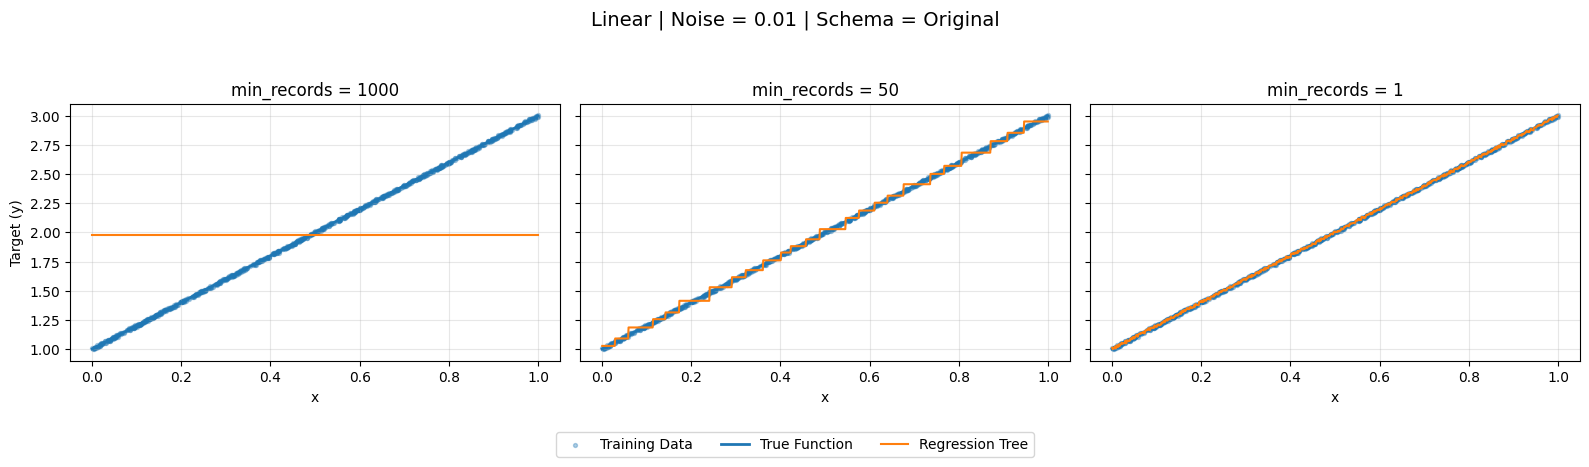

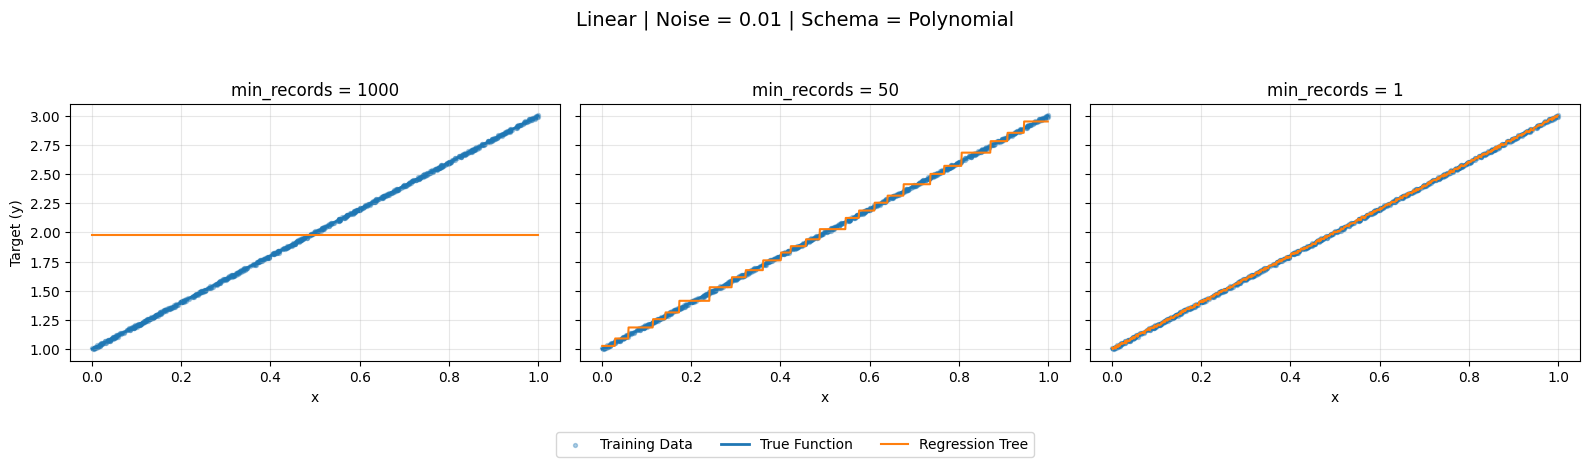

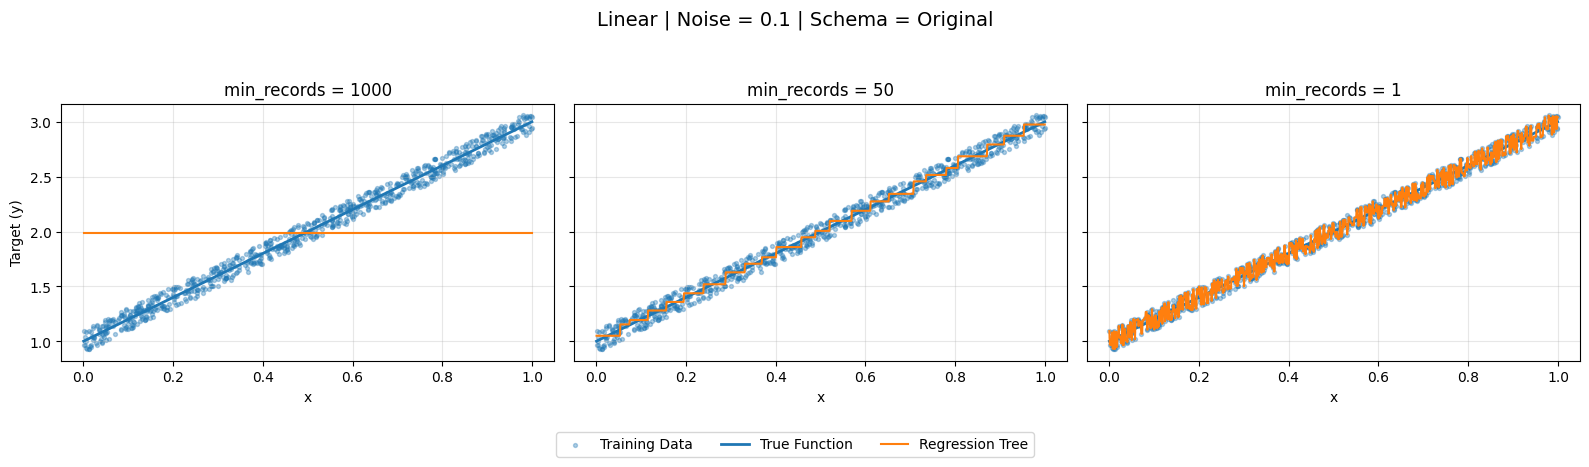

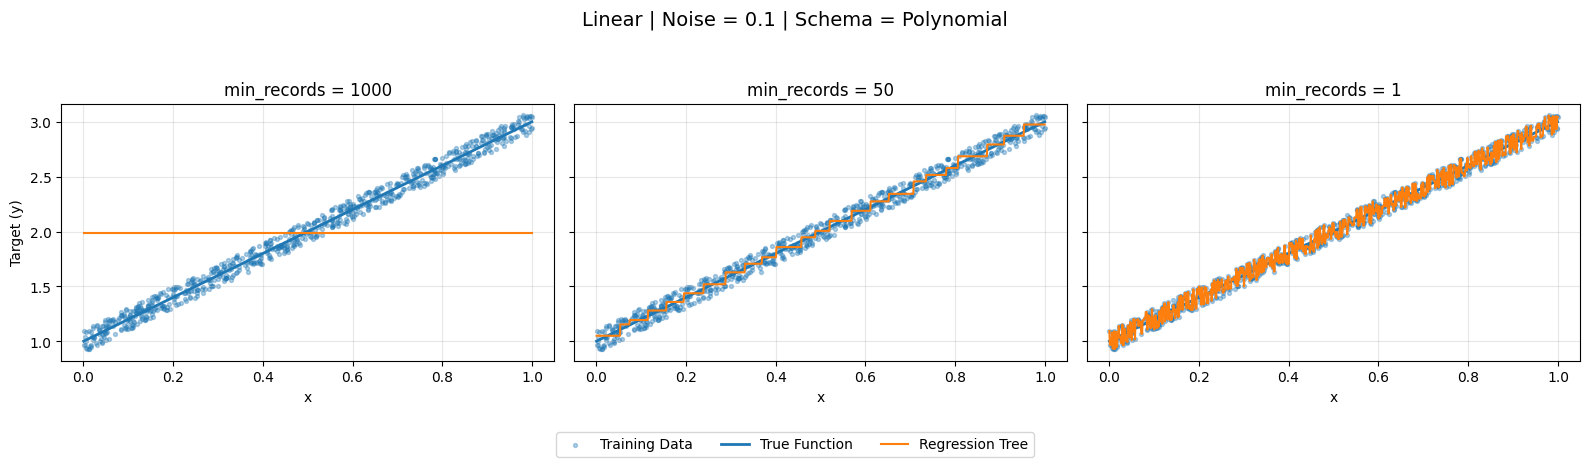

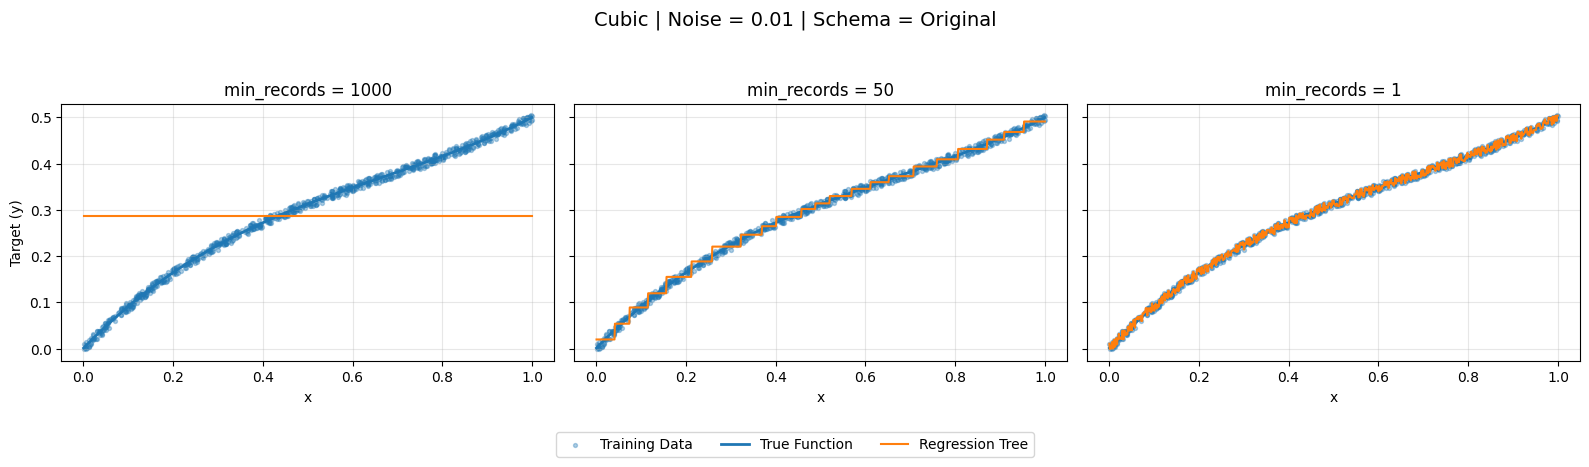

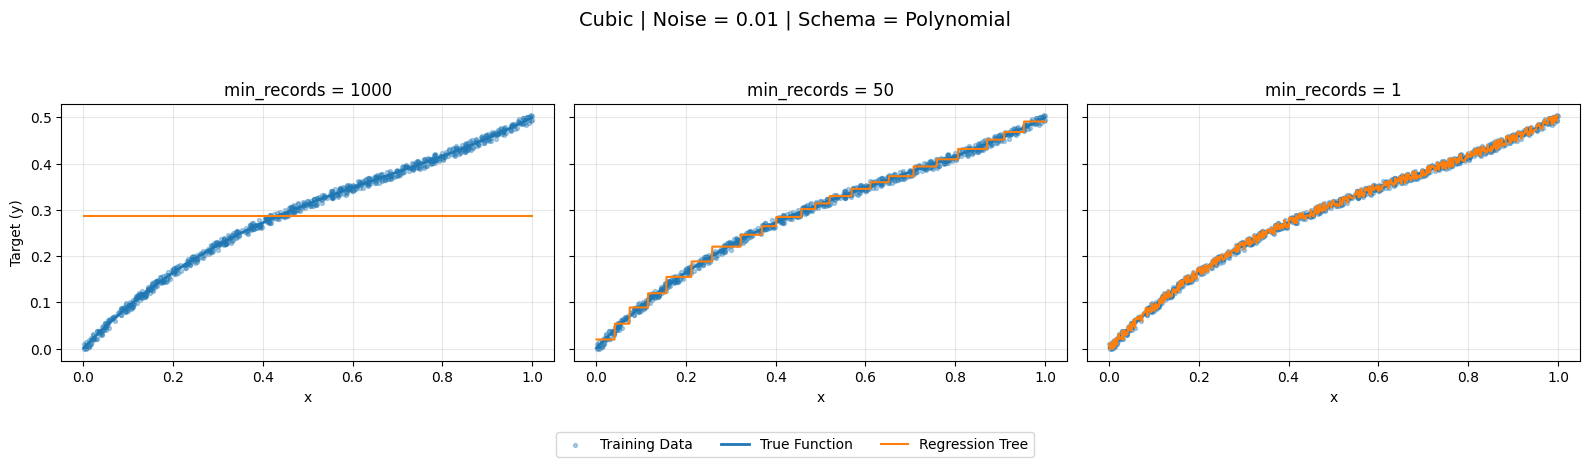

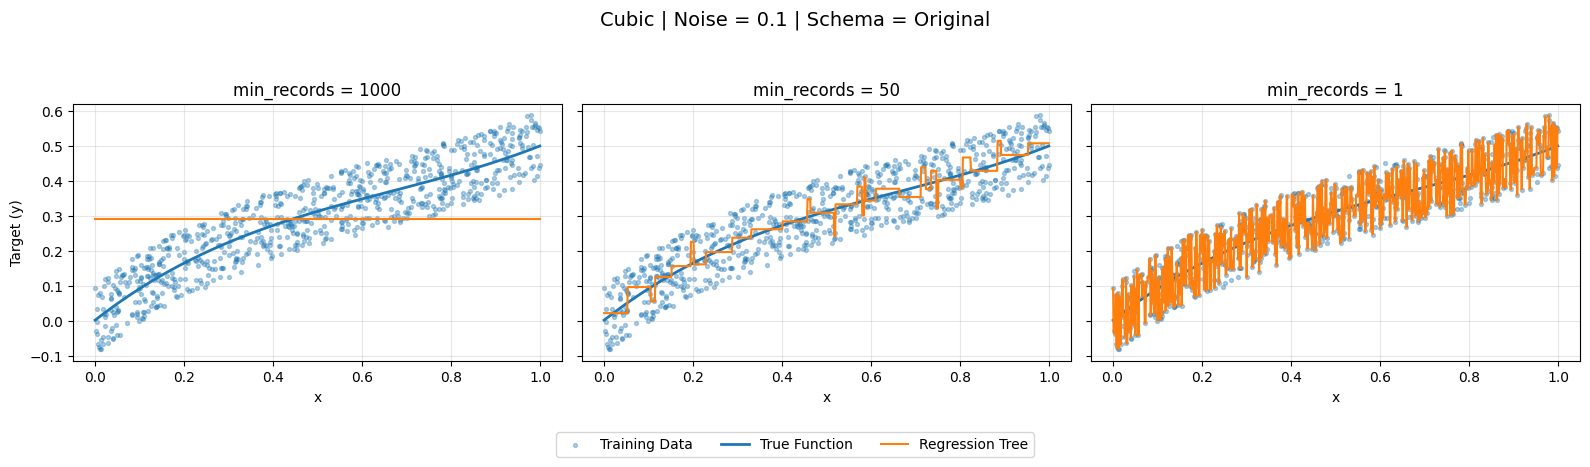

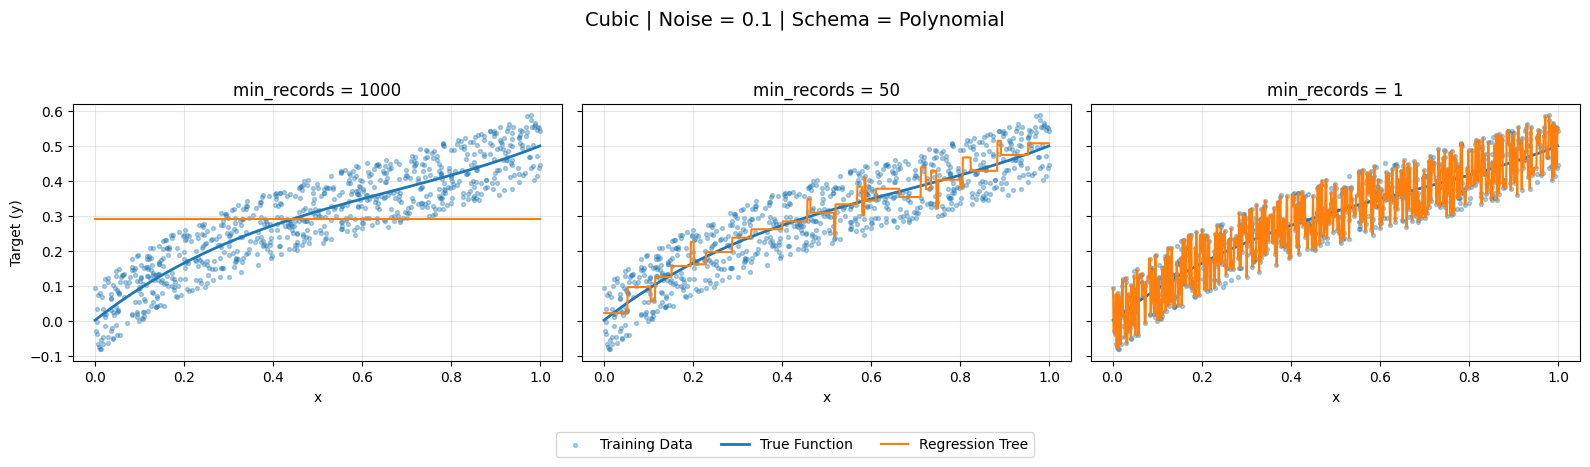

In [52]:

# Step 5B: Visualize all 24 regression tree experiments

import numpy as np
import matplotlib.pyplot as plt

def true_function_q9(x, function):
    if function == "Linear":
        return 2 * x + 1
    elif function == "Cubic":
        return 0.5 * x**3 - x**2 + x
    else:
        raise ValueError("Unknown function")


for function in ["Linear", "Cubic"]:
    for noise in [0.01, 0.1]:
        for schema in ["Original", "Polynomial"]:

            train_set, test_set = datasets_q9[
                (function, noise, schema)
            ]

            x_train = train_set[:, 0]
            y_train = train_set[:, -1]

            x_grid = np.linspace(
                x_train.min(),
                x_train.max(),
                1000
            )

            # Construct correct feature schema
            if schema == "Original":
                X_grid = x_grid.reshape(-1, 1)
            else:
                X_grid = np.column_stack([
                    x_grid,
                    x_grid**2,
                    x_grid**3
                ])

            y_true = true_function_q9(
                x_grid, function
            )

            fig, axes = plt.subplots(
                1, 3, figsize=(16, 4.5),
                sharex=True, sharey=True
            )

            for ax, min_records in zip(
                axes, [1000, 50, 1]
            ):

                model = trained_trees_q9[
                    (function, noise, schema, min_records)
                ]

                y_pred = model.predict(X_grid)

                ax.scatter(
                    x_train, y_train,
                    s=8, alpha=0.35,
                    label="Training Data"
                )

                ax.plot(
                    x_grid, y_true,
                    linewidth=2,
                    label="True Function"
                )

                ax.plot(
                    x_grid, y_pred,
                    linewidth=1.5,
                    label="Regression Tree"
                )

                ax.set_title(
                    f"min_records = {min_records}"
                )

                ax.set_xlabel("x")
                ax.grid(alpha=0.3)

            axes[0].set_ylabel("Target (y)")

            handles, labels = axes[0].get_legend_handles_labels()

            fig.legend(
                handles, labels,
                loc="lower center",
                ncol=3,
                bbox_to_anchor=(0.5, -0.03)
            )

            fig.suptitle(
                f"{function} | Noise = {noise} | "
                f"Schema = {schema}",
                fontsize=14
            )

            plt.tight_layout(rect=[0, 0.07, 1, 0.93])
            plt.show()


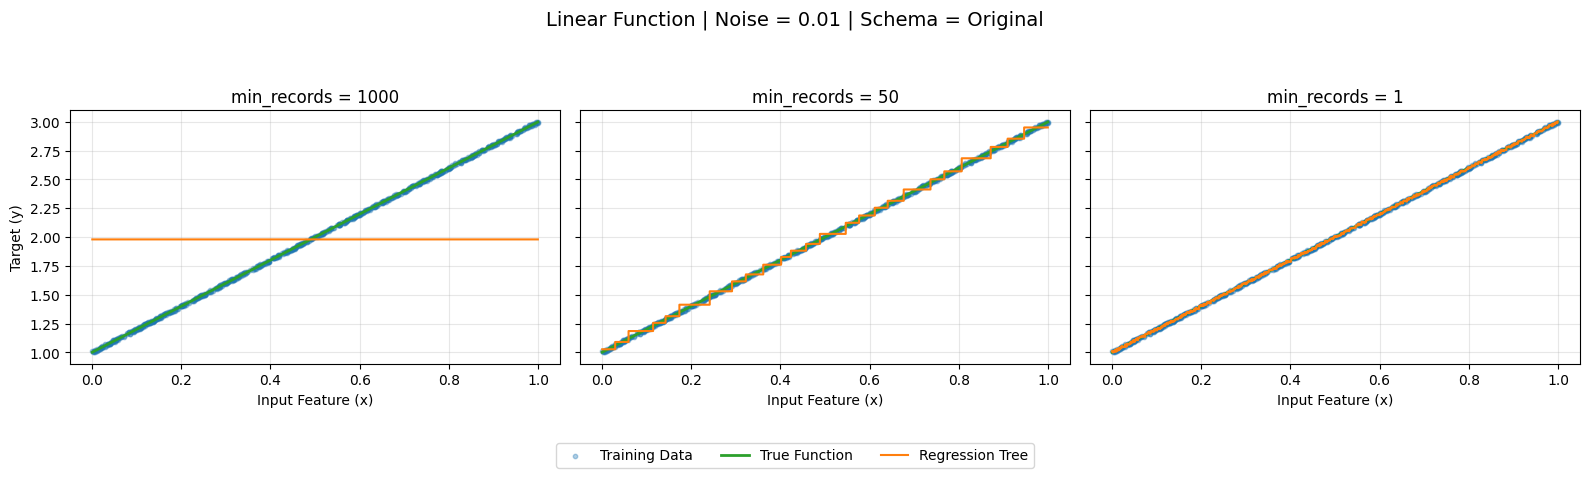

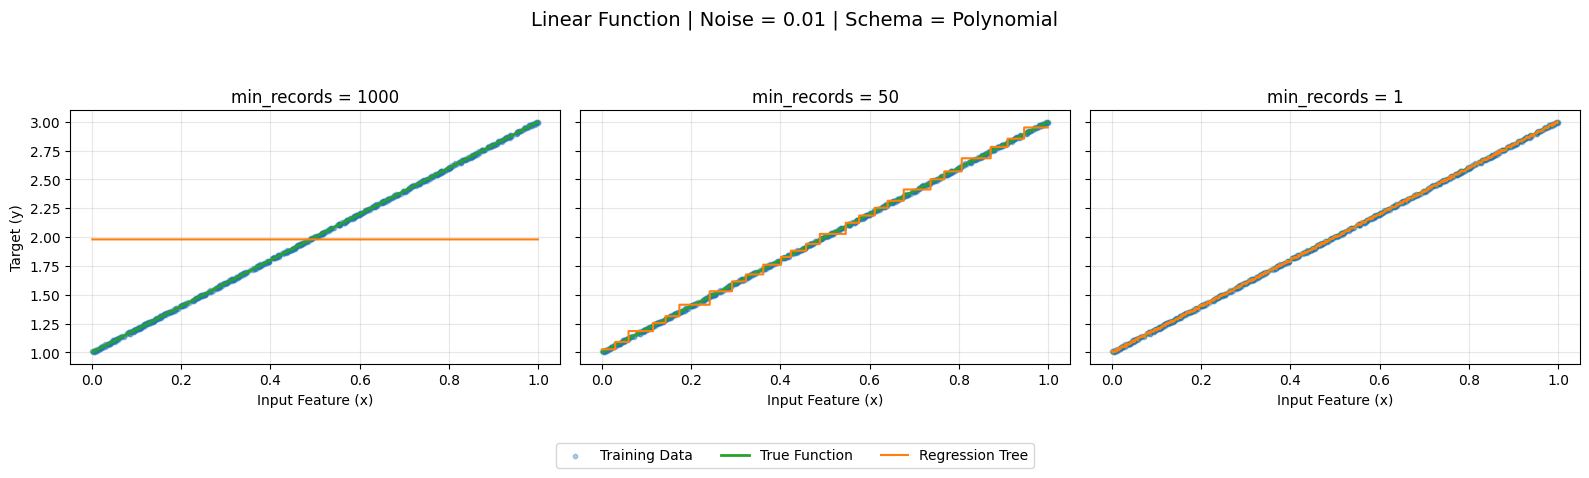

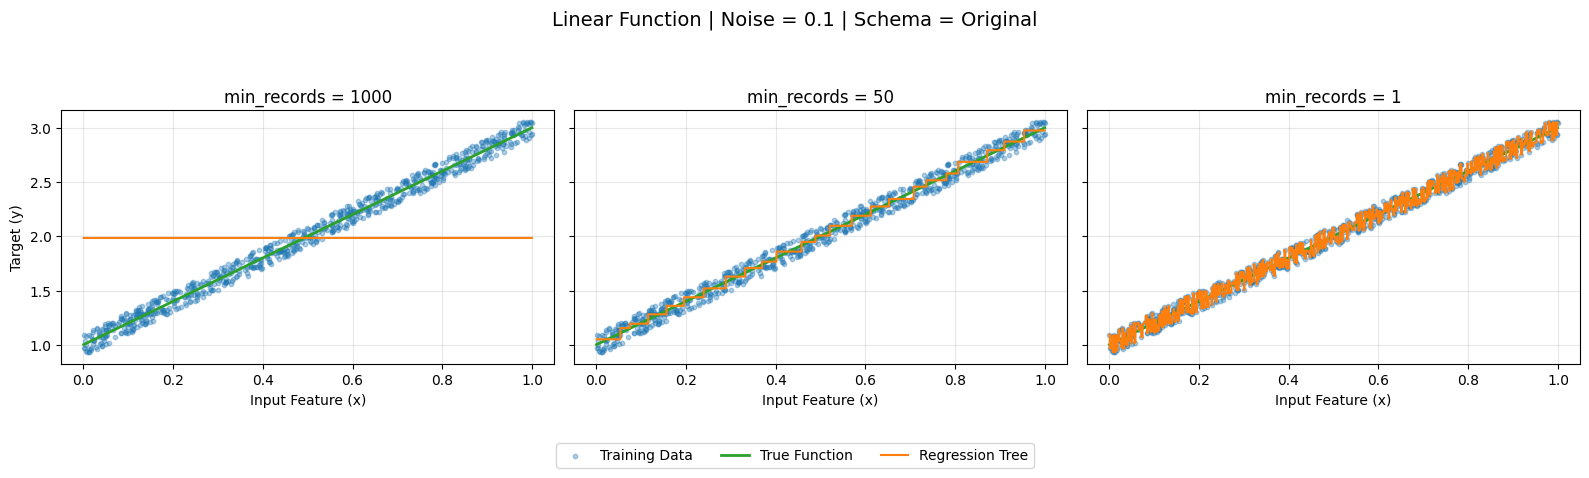

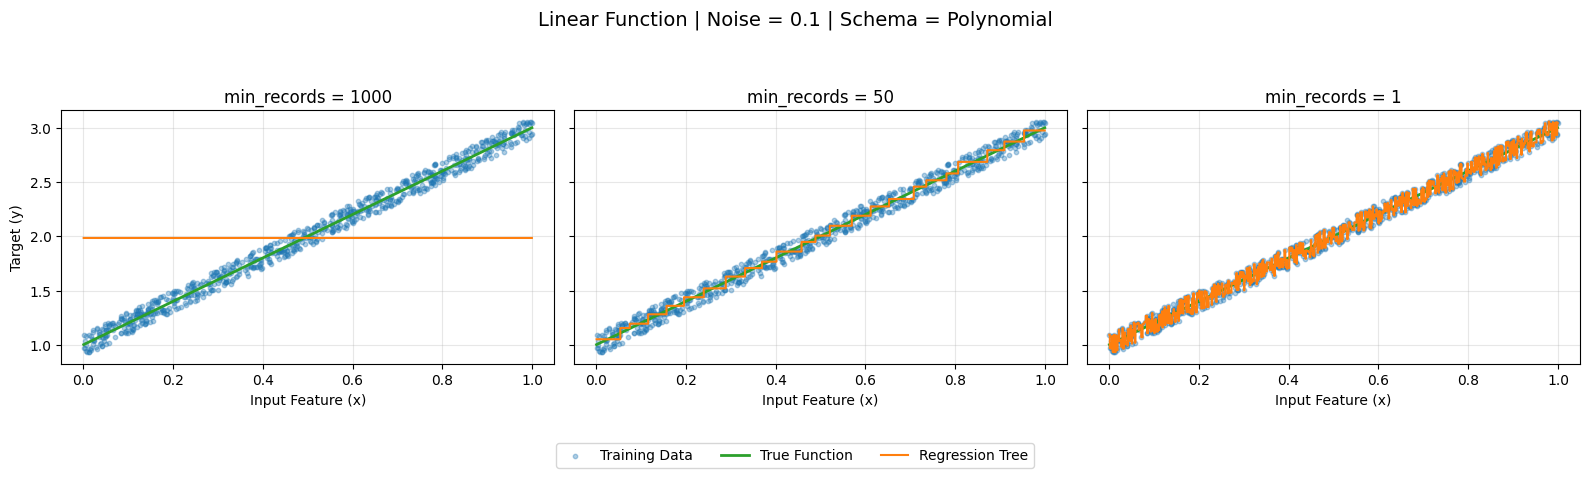

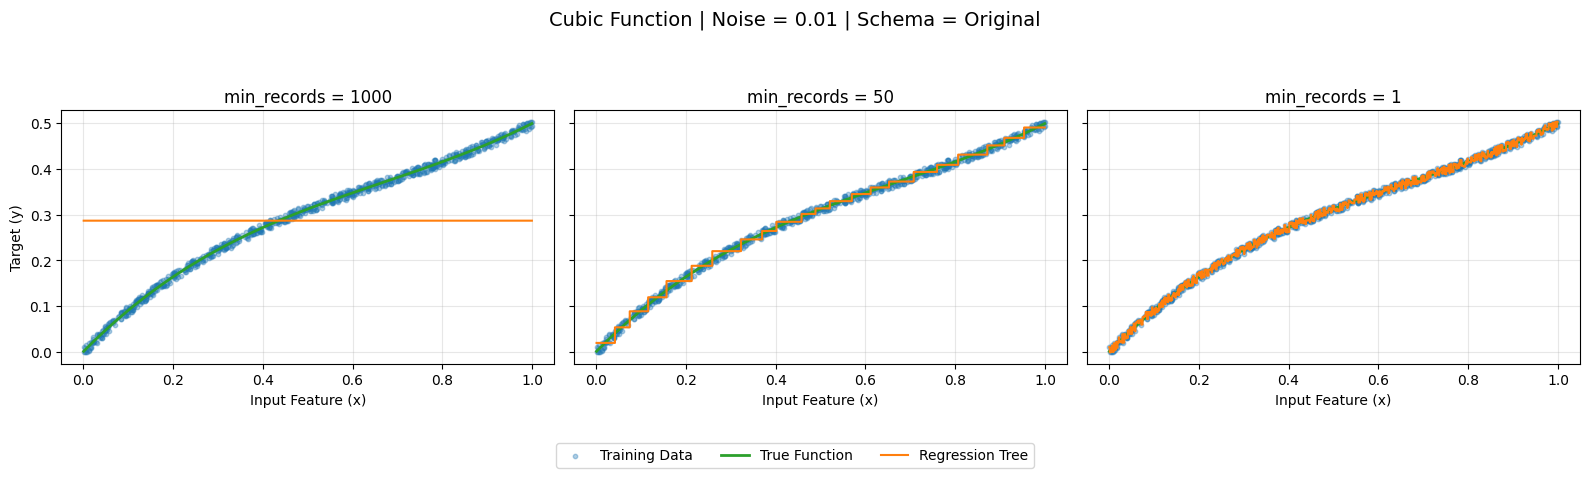

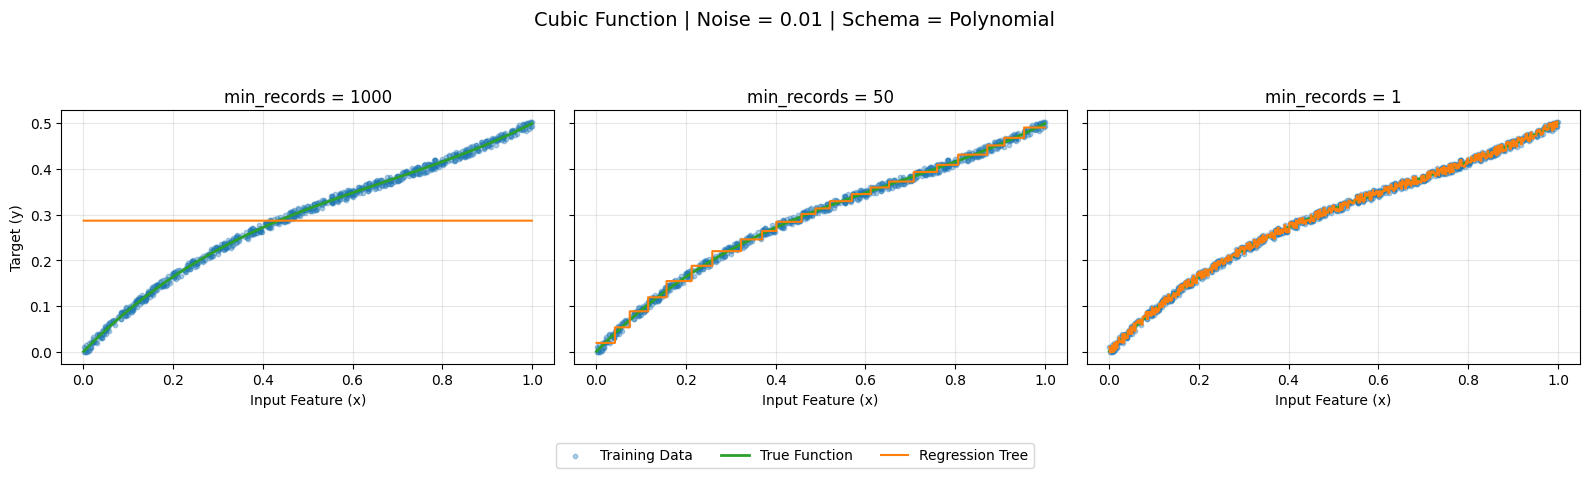

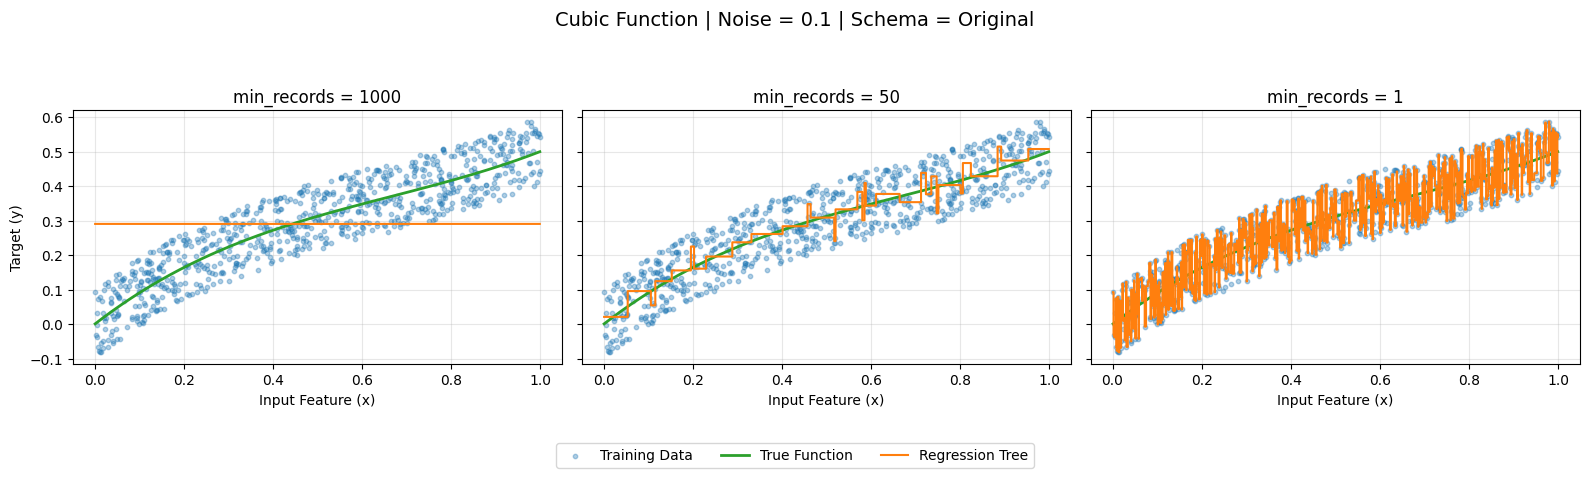

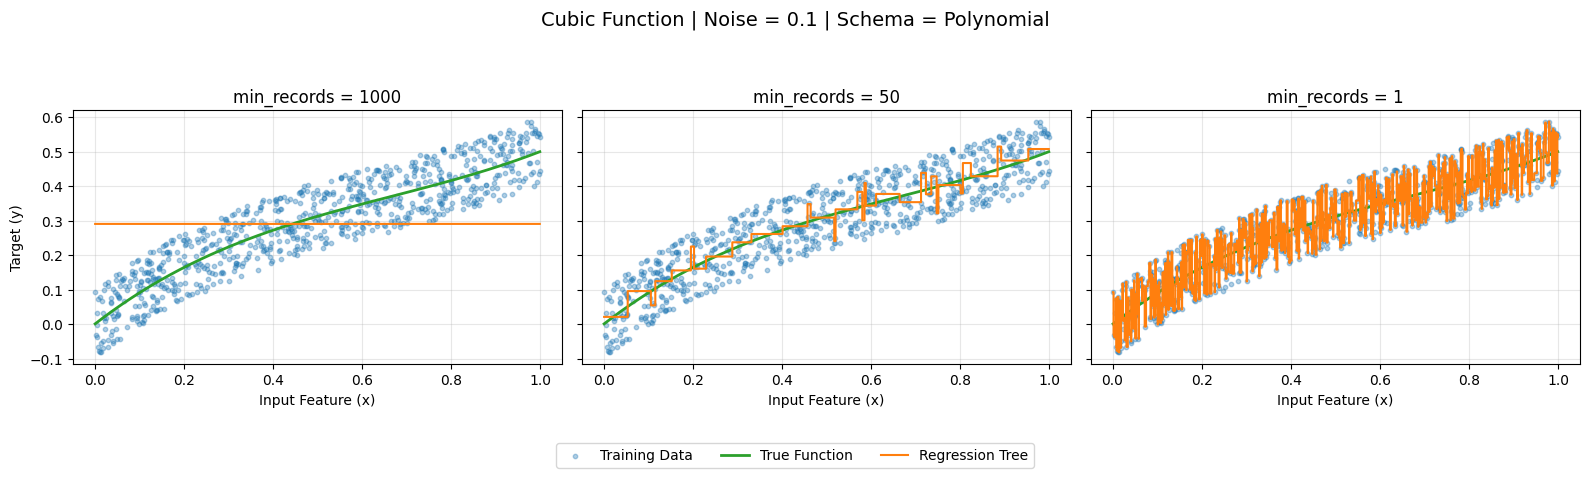


QUESTION 9: VISUALIZATION SUMMARY
Total dataset combinations: 8
Total figures generated: 8
Total experimental plots: 24

Saved PNG files:
Q9_Figures\Q9_Linear_noise_0.01_Original.png
Q9_Figures\Q9_Linear_noise_0.01_Polynomial.png
Q9_Figures\Q9_Linear_noise_0.1_Original.png
Q9_Figures\Q9_Linear_noise_0.1_Polynomial.png
Q9_Figures\Q9_Cubic_noise_0.01_Original.png
Q9_Figures\Q9_Cubic_noise_0.01_Polynomial.png
Q9_Figures\Q9_Cubic_noise_0.1_Original.png
Q9_Figures\Q9_Cubic_noise_0.1_Polynomial.png

Combined PDF: Q9_All_24_Regression_Tree_Plots.pdf

All 24 regression tree plots generated successfully.


In [53]:

# Step 5B + 5C: Visualize and save all 24 Q9 experiments

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# --------------------------------------------------
# 1. Create output directory
# --------------------------------------------------

output_dir = "Q9_Figures"
os.makedirs(output_dir, exist_ok=True)

pdf_path = "Q9_All_24_Regression_Tree_Plots.pdf"

# --------------------------------------------------
# 2. Define the true underlying functions
# --------------------------------------------------

def true_function_q9(x, function):

    if function == "Linear":
        return 2 * x + 1

    elif function == "Cubic":
        return 0.5 * x**3 - x**2 + x

    else:
        raise ValueError("Unknown true function.")

# --------------------------------------------------
# 3. Verify all 24 trained models are available
# --------------------------------------------------

assert len(datasets_q9) == 8

expected_keys = [
    (function, noise, schema, min_records)
    for function in ["Linear", "Cubic"]
    for noise in [0.01, 0.1]
    for schema in ["Original", "Polynomial"]
    for min_records in [1000, 50, 1]
]

missing_keys = [
    key for key in expected_keys
    if key not in trained_trees_q9
]

assert not missing_keys, (
    f"Missing trained models: {missing_keys}"
)

# --------------------------------------------------
# 4. Generate and save all 8 figures
# --------------------------------------------------

saved_files = []
plot_count = 0

with PdfPages(pdf_path) as pdf:

    for function in ["Linear", "Cubic"]:

        for noise in [0.01, 0.1]:

            for schema in ["Original", "Polynomial"]:

                # Retrieve the existing training dataset
                train_set, test_set = datasets_q9[
                    (function, noise, schema)
                ]

                x_train = train_set[:, 0]
                y_train = train_set[:, -1]

                # Generate evenly spaced input values
                x_grid = np.linspace(
                    x_train.min(),
                    x_train.max(),
                    1000
                )

                # Construct the appropriate feature schema
                if schema == "Original":

                    X_grid = x_grid.reshape(-1, 1)

                else:

                    X_grid = np.column_stack([
                        x_grid,
                        x_grid**2,
                        x_grid**3
                    ])

                # Evaluate the true underlying function
                y_true = true_function_q9(
                    x_grid, function
                )

                # Create three plots for min_records
                fig, axes = plt.subplots(
                    1, 3,
                    figsize=(16, 4.8),
                    sharex=True,
                    sharey=True
                )

                for ax, min_records in zip(
                    axes, [1000, 50, 1]
                ):

                    # Retrieve the trained regression tree
                    model = trained_trees_q9[
                        (
                            function,
                            noise,
                            schema,
                            min_records
                        )
                    ]

                    # Generate tree predictions
                    y_pred = model.predict(X_grid)

                    # Training observations
                    ax.scatter(
                        x_train,
                        y_train,
                        s=10,
                        alpha=0.35,
                        color="tab:blue",
                        label="Training Data",
                        zorder=2
                    )

                    # True underlying function
                    ax.plot(
                        x_grid,
                        y_true,
                        color="tab:green",
                        linewidth=2,
                        label="True Function",
                        zorder=3
                    )

                    # Regression tree predictions
                    ax.plot(
                        x_grid,
                        y_pred,
                        color="tab:orange",
                        linewidth=1.5,
                        drawstyle="steps-post",
                        label="Regression Tree",
                        zorder=4
                    )

                    ax.set_title(
                        f"min_records = {min_records}"
                    )

                    ax.set_xlabel("Input Feature (x)")
                    ax.grid(alpha=0.3)

                    plot_count += 1

                axes[0].set_ylabel("Target (y)")

                # Shared legend
                handles, labels = (
                    axes[0].get_legend_handles_labels()
                )

                fig.legend(
                    handles,
                    labels,
                    loc="lower center",
                    ncol=3,
                    bbox_to_anchor=(0.5, 0.01)
                )

                fig.suptitle(
                    f"{function} Function | "
                    f"Noise = {noise} | "
                    f"Schema = {schema}",
                    fontsize=14
                )

                fig.tight_layout(
                    rect=[0, 0.12, 1, 0.92]
                )

                # Save high-resolution PNG
                filename = (
                    f"Q9_{function}_"
                    f"noise_{noise}_{schema}.png"
                )

                image_path = os.path.join(
                    output_dir, filename
                )

                fig.savefig(
                    image_path,
                    dpi=200,
                    bbox_inches="tight"
                )

                saved_files.append(image_path)

                # Save same figure directly into PDF
                pdf.savefig(
                    fig,
                    bbox_inches="tight"
                )

                # Display figure in Jupyter Notebook
                plt.show()

                plt.close(fig)

# --------------------------------------------------
# 5. Verify final outputs
# --------------------------------------------------

assert len(saved_files) == 8
assert plot_count == 24
assert os.path.exists(pdf_path)

print("\n" + "=" * 55)
print("QUESTION 9: VISUALIZATION SUMMARY")
print("=" * 55)

print("Total dataset combinations:", len(datasets_q9))
print("Total figures generated:", len(saved_files))
print("Total experimental plots:", plot_count)

print("\nSaved PNG files:")

for filename in saved_files:
    print(filename)

print("\nCombined PDF:", pdf_path)

print("\nAll 24 regression tree plots generated successfully.")


###  Final Verification of Regression Tree Experiments

This step verifies that all 24 experimental combinations have been
evaluated using the custom regression tree implementation.

The verification checks:
1. Both true functions: Linear and Cubic.
2. Both noise levels: 0.01 and 0.1.
3. Both feature schemas: Original and Polynomial.
4. All three stopping values: 1000, 50, and 1.
5. Training and testing RMSE for every combination.

The corresponding visualizations contain the training data,
the true function, and the regression tree predictions.

In [54]:
# Q9: Final Verification of All 24 Regression Tree Experiments

from itertools import product
import numpy as np
import pandas as pd

# Use the existing Q9 results DataFrame
results_df = results_q9_df.copy()

# Generate all 24 expected experimental combinations
expected_combinations = set(product(
    ["Linear", "Cubic"],
    [0.01, 0.1],
    ["Original", "Polynomial"],
    [1000, 50, 1]
))

# Extract the actual experimental combinations
actual_combinations = set(
    zip(
        results_df["Function"],
        results_df["Noise"],
        results_df["Schema"],
        results_df["min_records"]
    )
)

print("Expected experiments:", len(expected_combinations))
print("Completed experiments:", len(actual_combinations))

# Verify all experimental combinations
assert expected_combinations == actual_combinations
assert len(results_df) == 24

# Verify RMSE values
assert results_df["Train RMSE"].notna().all()
assert results_df["Test RMSE"].notna().all()

assert np.isfinite(results_df["Train RMSE"]).all()
assert np.isfinite(results_df["Test RMSE"]).all()

assert (results_df["Train RMSE"] >= 0).all()
assert (results_df["Test RMSE"] >= 0).all()

print("\nAll 24 combinations verified successfully.")
print("All training and testing RMSE values are valid.")

# Display final verified results
display(
    results_df.sort_values(
        ["Function", "Noise", "Schema", "min_records"]
    ).reset_index(drop=True)
)

Expected experiments: 24
Completed experiments: 24

All 24 combinations verified successfully.
All training and testing RMSE values are valid.


,Function,Noise,Schema,min_records,Train RMSE,Test RMSE
0,Cubic,0.01,Original,1,0.000000,0.008300
1,Cubic,0.01,Original,50,0.008028,0.009074
2,Cubic,0.01,Original,1000,0.133197,0.133579
3,Cubic,0.01,Polynomial,1,0.000000,0.008300
4,Cubic,0.01,Polynomial,50,0.008028,0.009074
5,Cubic,0.01,Polynomial,1000,0.133197,0.133579
6,Cubic,0.10,Original,1,0.000000,0.082463
7,Cubic,0.10,Original,50,0.054868,0.057437
8,Cubic,0.10,Original,1000,0.145669,0.143885
9,Cubic,0.10,Polynomial,1,0.000000,0.082463



### Ans 9: Experimental Results and Observations

All 24 regression-tree experiments were completed successfully using two true functions (Linear and Cubic), two noise levels (0.01 and 0.1), two feature schemas (Original and Polynomial), and three stopping values (1000, 50, and 1).

**Key Observations:**

1. **Effect of min_records:** With min_records = 1000, the regression tree underfits and produces relatively high training and testing RMSE. With min_records = 50, the tree captures the underlying relationship more accurately. With min_records = 1, training RMSE becomes zero, indicating an exact fit to the training observations.

2. **Effect of Noise:** Increasing the noise level from 0.01 to 0.1 generally increases testing RMSE, making accurate predictions more difficult.

3. **Effect of Feature Schema:** The Original and Polynomial feature schemas produce identical RMSE values in the evaluated experiments, indicating that the additional polynomial features did not improve the regression tree's predictive performance.

4. **Regression Tree Visualization:** The tree produces piecewise-constant predictions. Smaller min_records values allow more splits and a closer fit to the training observations.

**Conclusion:**

The experiments demonstrate how the minimum-record stopping parameter affects regression-tree complexity and predictive performance. Larger stopping values cause underfitting, while smaller values produce more flexible trees. Although min_records = 1 achieves zero training error, this alone does not establish better generalization. The testing RMSE must also be considered.



# Answer 10: Regression Trees vs. Linear Regression Models

## Experimental Comparison

This question compares the regression trees from Question 9 with the corresponding linear regression models trained on the same datasets.

The evaluation considers:

1. Training and testing RMSE for both models.
2. The effect of adding polynomial input features.
3. Regression-tree size, including the number of nodes and records in each leaf.
4. The effect of noise on predictive performance.

The comparisons use the existing Linear and Cubic datasets, noise levels of 0.01 and 0.1, and Original and Polynomial feature schemas.

Testing RMSE is used to determine which model performs better on unseen data.


In [55]:
# Ans 10 : Identify existing linear regression results

import pandas as pd

for name, obj in list(globals().items()):

    if isinstance(obj, pd.DataFrame):

        if any(
            keyword in name.lower()
            for keyword in ["result", "comparison", "rmse"]
        ):
            print(f"\nDataFrame: {name}")
            print("Shape:", obj.shape)
            print("Columns:", obj.columns.tolist())


DataFrame: results_ans_3
Shape: (4, 4)
Columns: ['True Function', 'Noise Level', 'Training RMSE', 'Testing RMSE']

DataFrame: comparison_q4
Shape: (4, 5)
Columns: ['True Function', 'Noise Level', 'Q3 Test RMSE', 'Q4 Test RMSE', 'Improvement (%)']

DataFrame: results_q5_df
Shape: (8, 6)
Columns: ['True Function', 'Noise', 'Schema', 'True y', 'Predicted y', 'Absolute Error']

DataFrame: comparison_q6c
Shape: (8, 6)
Columns: ['True Function', 'Noise Level', 'Model', 'Test RMSE', 'Irreducible RMSE', 'Absolute RMSE Gap']

DataFrame: results_q7
Shape: (10, 3)
Columns: ['Polynomial Degree', 'Training RMSE', 'Testing RMSE']

DataFrame: results_q9_df
Shape: (24, 6)
Columns: ['Function', 'Noise', 'Schema', 'min_records', 'Train RMSE', 'Test RMSE']

DataFrame: results_df
Shape: (24, 6)
Columns: ['Function', 'Noise', 'Schema', 'min_records', 'Train RMSE', 'Test RMSE']


In [56]:
#  Inspect existing linear regression results

print("Q3: Linear Regression Results")
display(results_ans_3)

print("\nQ6: Model Comparison Results")
display(comparison_q6c)

print("\nQ9: Regression Tree Results (First 8 Rows)")
display(results_q9_df.head(8))

Q3: Linear Regression Results


,True Function,Noise Level,Training RMSE,Testing RMSE
0,Linear,0.01,0.005877,0.005415
1,Linear,0.10,0.058774,0.054153
2,Cubic,0.01,0.021657,0.021498
3,Cubic,0.10,0.062319,0.059390



Q6: Model Comparison Results


,True Function,Noise Level,Model,Test RMSE,Irreducible RMSE,Absolute RMSE Gap
0,Linear,0.01,Original,0.005415,0.005774,0.000358
1,Linear,0.01,Polynomial,0.005432,0.005774,0.000342
2,Linear,0.10,Original,0.054153,0.057735,0.003582
3,Linear,0.10,Polynomial,0.054318,0.057735,0.003417
4,Cubic,0.01,Original,0.021498,0.005774,0.015725
5,Cubic,0.01,Polynomial,0.005432,0.005774,0.000342
6,Cubic,0.10,Original,0.059390,0.057735,0.001655
7,Cubic,0.10,Polynomial,0.054318,0.057735,0.003417



Q9: Regression Tree Results (First 8 Rows)


,Function,Noise,Schema,min_records,Train RMSE,Test RMSE
0,Linear,0.01,Original,1000,0.579902,0.595680
1,Linear,0.01,Original,50,0.025145,0.026044
2,Linear,0.01,Original,1,0.000000,0.008636
3,Linear,0.01,Polynomial,1000,0.579902,0.595680
4,Linear,0.01,Polynomial,50,0.025145,0.026044
5,Linear,0.01,Polynomial,1,0.000000,0.008636
6,Linear,0.10,Original,1000,0.583083,0.597361
7,Linear,0.10,Original,50,0.056354,0.061611


In [57]:
#  Compare Linear Regression and Regression Trees

import pandas as pd
import numpy as np

# Extract linear regression testing RMSE
linear_results = comparison_q6c[
    ["True Function", "Noise Level", "Model", "Test RMSE"]
].copy()

linear_results = linear_results.rename(columns={
    "True Function": "Function",
    "Noise Level": "Noise",
    "Model": "Schema",
    "Test RMSE": "Linear RMSE"
})

# Extract regression tree testing RMSE
tree_results = results_q9_df[
    ["Function", "Noise", "Schema", "min_records", "Test RMSE"]
].copy()

tree_results = tree_results.rename(columns={
    "Test RMSE": "Tree RMSE"
})

# Match the same function, noise level, and feature schema
comparison_q10 = pd.merge(
    tree_results,
    linear_results,
    on=["Function", "Noise", "Schema"],
    how="inner",
    validate="many_to_one"
)

# Identify the better model using testing RMSE
comparison_q10["Winner"] = np.where(
    comparison_q10["Tree RMSE"] < comparison_q10["Linear RMSE"],
    "Regression Tree",
    np.where(
        comparison_q10["Tree RMSE"] > comparison_q10["Linear RMSE"],
        "Linear Regression",
        "Tie"
    )
)

# Sort the results
comparison_q10 = comparison_q10.sort_values(
    ["Function", "Noise", "Schema", "min_records"]
).reset_index(drop=True)

# Verify all 24 comparisons
assert len(comparison_q10) == 24

assert comparison_q10[
    ["Tree RMSE", "Linear RMSE"]
].notna().all().all()

print("Total comparisons:", len(comparison_q10))

display(
    comparison_q10[
        [
            "Function",
            "Noise",
            "Schema",
            "min_records",
            "Linear RMSE",
            "Tree RMSE",
            "Winner"
        ]
    ]
)

print("\nWinner Summary:")
print(comparison_q10["Winner"].value_counts())

Total comparisons: 24


,Function,Noise,Schema,min_records,Linear RMSE,Tree RMSE,Winner
0,Cubic,0.01,Original,1,0.021498,0.008300,Regression Tree
1,Cubic,0.01,Original,50,0.021498,0.009074,Regression Tree
2,Cubic,0.01,Original,1000,0.021498,0.133579,Linear Regression
3,Cubic,0.01,Polynomial,1,0.005432,0.008300,Linear Regression
4,Cubic,0.01,Polynomial,50,0.005432,0.009074,Linear Regression
5,Cubic,0.01,Polynomial,1000,0.005432,0.133579,Linear Regression
6,Cubic,0.10,Original,1,0.059390,0.082463,Linear Regression
7,Cubic,0.10,Original,50,0.059390,0.057437,Regression Tree
8,Cubic,0.10,Original,1000,0.059390,0.143885,Linear Regression
9,Cubic,0.10,Polynomial,1,0.054318,0.082463,Linear Regression



Winner Summary:
Winner
Linear Regression    21
Regression Tree       3
Name: count, dtype: int64


In [58]:
# Step 5A: Inspect RegressionTree Structure
# Works without inspect.getsource()

print("RegressionTree class attributes:")
print([
    name for name in dir(RegressionTree)
    if not name.startswith("__")
])

print("\nRegressionTree constructor:")
import inspect

print(inspect.signature(RegressionTree))

print("\nAvailable tree-related objects:")

for name in [
    "RegressionTree",
    "Node",
    "TreeNode",
    "build_tree",
    "find_best_split",
    "datasets_q9",
    "splits_q9"
]:
    if name in globals():
        obj = globals()[name]
        print(f"{name}: {type(obj).__name__}")

print("\nSample RegressionTree instance:")

sample_tree = RegressionTree()

print("Instance attributes:")
print(vars(sample_tree))

RegressionTree class attributes:
['_predict_one', 'fit', 'predict', 'visualize']

RegressionTree constructor:
()

Available tree-related objects:
RegressionTree: type
build_tree: function
find_best_split: function
datasets_q9: dict

Sample RegressionTree instance:
Instance attributes:
{'tree': None, 'n_features': None}


In [59]:
# Q10 Step 5B: Inspect Trained Regression Tree Nodes

# Select one existing Q9 dataset
key = ("Linear", 0.01, "Original")

train_data, test_data = datasets_q9[key]

# Train the custom regression tree
sample_tree = RegressionTree()
sample_tree.fit(train_data, min_records=50)

# Access the root node
root = sample_tree.tree

print("Root node type:")
print(type(root))

print("\nRoot node keys:")
print(list(root.keys()))

print("\nRoot node values:")

for key, value in root.items():
    if isinstance(value, dict):
        print(f"{key}: child node (dictionary)")
    else:
        print(f"{key}: {value}")

# Inspect child nodes
for child_name in ["left", "right"]:

    child = root.get(child_name)

    if isinstance(child, dict):

        print(f"\n{child_name.capitalize()} child keys:")
        print(list(child.keys()))

        print(f"\n{child_name.capitalize()} child values:")

        for key, value in child.items():

            if isinstance(value, dict):
                print(f"{key}: child node (dictionary)")
            else:
                print(f"{key}: {value}")

Root node type:
<class 'dict'>

Root node keys:
['feature', 'threshold', 'prediction', 'left', 'right']

Root node values:
feature: 0
threshold: 0.4880801686726842
prediction: 1.9802810669001376
left: child node (dictionary)
right: child node (dictionary)

Left child keys:
['feature', 'threshold', 'prediction', 'left', 'right']

Left child values:
feature: 0
threshold: 0.24117131831617383
prediction: 1.4756658267789586
left: child node (dictionary)
right: child node (dictionary)

Right child keys:
['feature', 'threshold', 'prediction', 'left', 'right']

Right child values:
feature: 0
threshold: 0.7359175580009268
prediction: 2.482379522781311
left: child node (dictionary)
right: child node (dictionary)


In [60]:

# Q10 Step 5C: Analyze Tree Size and Leaf Records
# Uses the custom RegressionTree implementation from Q8
# and the original training datasets from Q9.

import numpy as np
import pandas as pd


# 1. Count internal nodes and leaf nodes recursively

def count_tree_nodes(node):

    if node is None:
        return 0, 0

    # Leaf nodes have no split feature
    if node.get("feature") is None:
        return 0, 1

    left_internal, left_leaves = count_tree_nodes(
        node["left"]
    )

    right_internal, right_leaves = count_tree_nodes(
        node["right"]
    )

    return (
        1 + left_internal + right_internal,
        left_leaves + right_leaves
    )


# 2. Count training records reaching every leaf

def get_leaf_sizes(node, X):

    # Reached a leaf node
    if node.get("feature") is None:
        return [len(X)]

    feature = node["feature"]
    threshold = node["threshold"]

    # Apply the same splitting rule as Q8
    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold

    left_sizes = get_leaf_sizes(
        node["left"],
        X[left_mask]
    )

    right_sizes = get_leaf_sizes(
        node["right"],
        X[right_mask]
    )

    return left_sizes + right_sizes


# 3. Calculate statistics for all 24 experiments

tree_statistics = []

for (function, noise, schema), (train_data, test_data) in datasets_q9.items():

    train_array = np.asarray(train_data, dtype=float)
    X_train = train_array[:, :-1]

    for min_records in [1000, 50, 1]:

        # Train the custom regression tree
        model = RegressionTree()
        model.fit(train_data, min_records=min_records)

        # Count internal and leaf nodes
        internal_nodes, leaf_nodes = count_tree_nodes(
            model.tree
        )

        total_nodes = internal_nodes + leaf_nodes

        # Count records reaching each leaf
        leaf_sizes = get_leaf_sizes(
            model.tree, X_train
        )

        # Validate tree structure
        assert len(leaf_sizes) == leaf_nodes
        assert sum(leaf_sizes) == len(X_train)
        assert total_nodes == 2 * leaf_nodes - 1
        assert all(size > 0 for size in leaf_sizes)

        # Store experimental statistics
        tree_statistics.append({
            "Function": function,
            "Noise": noise,
            "Schema": schema,
            "min_records": min_records,
            "Total Nodes": total_nodes,
            "Internal Nodes": internal_nodes,
            "Leaf Nodes": leaf_nodes,
            "Min Leaf Size": min(leaf_sizes),
            "Max Leaf Size": max(leaf_sizes),
            "Mean Leaf Size": np.mean(leaf_sizes),
            "Leaf Sizes": leaf_sizes
        })


# 4. Create the results DataFrame

tree_stats_df = pd.DataFrame(tree_statistics)

tree_stats_df = tree_stats_df.sort_values(
    ["Function", "Noise", "Schema", "min_records"]
).reset_index(drop=True)


# 5. Verify all experimental combinations

from itertools import product

expected_combinations = set(
    product(
        ["Linear", "Cubic"],
        [0.01, 0.1],
        ["Original", "Polynomial"],
        [1000, 50, 1]
    )
)

actual_combinations = set(
    zip(
        tree_stats_df["Function"],
        tree_stats_df["Noise"],
        tree_stats_df["Schema"],
        tree_stats_df["min_records"]
    )
)

assert len(tree_stats_df) == 24
assert expected_combinations == actual_combinations

print("Total tree configurations:", len(tree_stats_df))
print("All 24 tree configurations verified successfully.")


# 6. Display tree size and leaf statistics

print("\nQ10: Regression Tree Size and Leaf Statistics")

display(
    tree_stats_df[
        [
            "Function",
            "Noise",
            "Schema",
            "min_records",
            "Total Nodes",
            "Internal Nodes",
            "Leaf Nodes",
            "Min Leaf Size",
            "Max Leaf Size",
            "Mean Leaf Size"
        ]
    ]
)


# 7. Display the exact number of records in every leaf

print("\nQ10: Exact Leaf Record Counts")

display(
    tree_stats_df[
        [
            "Function",
            "Noise",
            "Schema",
            "min_records",
            "Leaf Sizes"
        ]
    ]
)


# 8. Final verification

print("\nAll 24 tree statistics calculated successfully.")
print("Node counts and leaf record counts verified.")


Total tree configurations: 24
All 24 tree configurations verified successfully.

Q10: Regression Tree Size and Leaf Statistics


,Function,Noise,Schema,min_records,Total Nodes,Internal Nodes,Leaf Nodes,Min Leaf Size,Max Leaf Size,Mean Leaf Size
0,Cubic,0.01,Original,1,1599,799,800,1,1,1.000000
1,Cubic,0.01,Original,50,43,21,22,26,49,36.363636
2,Cubic,0.01,Original,1000,1,0,1,800,800,800.000000
3,Cubic,0.01,Polynomial,1,1599,799,800,1,1,1.000000
4,Cubic,0.01,Polynomial,50,43,21,22,26,49,36.363636
5,Cubic,0.01,Polynomial,1000,1,0,1,800,800,800.000000
6,Cubic,0.10,Original,1,1599,799,800,1,1,1.000000
7,Cubic,0.10,Original,50,65,32,33,2,49,24.242424
8,Cubic,0.10,Original,1000,1,0,1,800,800,800.000000
9,Cubic,0.10,Polynomial,1,1599,799,800,1,1,1.000000



Q10: Exact Leaf Record Counts


,Function,Noise,Schema,min_records,Leaf Sizes
0,Cubic,0.01,Original,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,Cubic,0.01,Original,50,"[34, 27, 37, 48, 43, 34, 49, 28, 27, 45, 27, 2..."
2,Cubic,0.01,Original,1000,[800]
3,Cubic,0.01,Polynomial,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,Cubic,0.01,Polynomial,50,"[34, 27, 37, 48, 43, 34, 49, 28, 27, 45, 27, 2..."
5,Cubic,0.01,Polynomial,1000,[800]
6,Cubic,0.10,Original,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
7,Cubic,0.10,Original,50,"[48, 40, 10, 42, 34, 6, 17, 45, 37, 48, 45, 6,..."
8,Cubic,0.10,Original,1000,[800]
9,Cubic,0.10,Polynomial,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."



All 24 tree statistics calculated successfully.
Node counts and leaf record counts verified.


Q10: Tree Size and Prediction Performance


,Function,Noise,Schema,min_records,Total Nodes,Leaf Nodes,Mean Leaf Size,Train RMSE,Test RMSE
0,Cubic,0.01,Original,1,1599,800,1.000000,0.000000,0.008300
1,Cubic,0.01,Original,50,43,22,36.363636,0.008028,0.009074
2,Cubic,0.01,Original,1000,1,1,800.000000,0.133197,0.133579
3,Cubic,0.01,Polynomial,1,1599,800,1.000000,0.000000,0.008300
4,Cubic,0.01,Polynomial,50,43,22,36.363636,0.008028,0.009074
5,Cubic,0.01,Polynomial,1000,1,1,800.000000,0.133197,0.133579
6,Cubic,0.10,Original,1,1599,800,1.000000,0.000000,0.082463
7,Cubic,0.10,Original,50,65,33,24.242424,0.054868,0.057437
8,Cubic,0.10,Original,1000,1,1,800.000000,0.145669,0.143885
9,Cubic,0.10,Polynomial,1,1599,800,1.000000,0.000000,0.082463



Average Performance by min_records:


,min_records,Average_Nodes,Average_Leaves,Average_Train_RMSE,Average_Test_RMSE
0,1,1599.0,800.0,0.000000,0.045506
1,50,51.0,26.0,0.036099,0.038541
2,1000,1.0,1.0,0.360463,0.367626


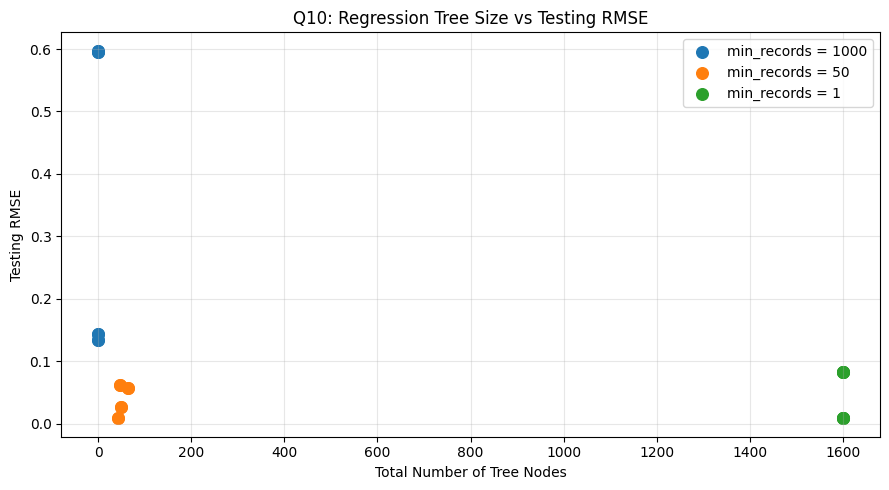


All 24 tree-size and RMSE comparisons completed.


In [61]:
# Q10 Step 5D: Tree Size vs Testing RMSE

import pandas as pd
import matplotlib.pyplot as plt

# Merge Q9 regression-tree results with Q10 tree statistics
tree_size_comparison = pd.merge(
    tree_stats_df,
    results_q9_df[
        [
            "Function",
            "Noise",
            "Schema",
            "min_records",
            "Train RMSE",
            "Test RMSE"
        ]
    ],
    on=["Function", "Noise", "Schema", "min_records"],
    how="inner",
    validate="one_to_one"
)

# Verify all 24 experiments are retained
assert len(tree_size_comparison) == 24

print("Q10: Tree Size and Prediction Performance")

display(
    tree_size_comparison[
        [
            "Function",
            "Noise",
            "Schema",
            "min_records",
            "Total Nodes",
            "Leaf Nodes",
            "Mean Leaf Size",
            "Train RMSE",
            "Test RMSE"
        ]
    ].sort_values(
        ["Function", "Noise", "Schema", "min_records"]
    ).reset_index(drop=True)
)

# Compare testing RMSE across tree sizes
summary = (
    tree_size_comparison
    .groupby("min_records")
    .agg(
        Average_Nodes=("Total Nodes", "mean"),
        Average_Leaves=("Leaf Nodes", "mean"),
        Average_Train_RMSE=("Train RMSE", "mean"),
        Average_Test_RMSE=("Test RMSE", "mean")
    )
    .reset_index()
)

print("\nAverage Performance by min_records:")
display(summary)

# Plot tree size against testing RMSE
plt.figure(figsize=(9, 5))

for min_records in [1000, 50, 1]:

    subset = tree_size_comparison[
        tree_size_comparison["min_records"] == min_records
    ]

    plt.scatter(
        subset["Total Nodes"],
        subset["Test RMSE"],
        label=f"min_records = {min_records}",
        s=70
    )

plt.xlabel("Total Number of Tree Nodes")
plt.ylabel("Testing RMSE")
plt.title("Q10: Regression Tree Size vs Testing RMSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAll 24 tree-size and RMSE comparisons completed.")

In [62]:
# Q10 Step 6: Effect of Additional Polynomial Features

import pandas as pd
import numpy as np

# Compare original and polynomial feature schemas
schema_comparison = tree_size_comparison.pivot(
    index=["Function", "Noise", "min_records"],
    columns="Schema",
    values=["Test RMSE", "Total Nodes", "Leaf Nodes"]
)

schema_comparison.columns = [
    f"{metric}_{schema}"
    for metric, schema in schema_comparison.columns
]

schema_comparison = schema_comparison.reset_index()

# Calculate differences
schema_comparison["RMSE Difference"] = (
    schema_comparison["Test RMSE_Polynomial"]
    - schema_comparison["Test RMSE_Original"]
)

schema_comparison["Node Difference"] = (
    schema_comparison["Total Nodes_Polynomial"]
    - schema_comparison["Total Nodes_Original"]
)

schema_comparison["Leaf Difference"] = (
    schema_comparison["Leaf Nodes_Polynomial"]
    - schema_comparison["Leaf Nodes_Original"]
)

display(schema_comparison)

# Verify equality across corresponding configurations
assert len(schema_comparison) == 12

assert np.allclose(
    schema_comparison["RMSE Difference"], 0
)

assert (schema_comparison["Node Difference"] == 0).all()

assert (schema_comparison["Leaf Difference"] == 0).all()

print("\nAll 12 schema comparisons verified successfully.")
print("Polynomial features do not change testing RMSE.")
print("Polynomial features do not change node or leaf counts.")

,Function,Noise,min_records,Test RMSE_Original,Test RMSE_Polynomial,Total Nodes_Original,Total Nodes_Polynomial,Leaf Nodes_Original,Leaf Nodes_Polynomial,RMSE Difference,Node Difference,Leaf Difference
0,Cubic,0.01,1,0.008300,0.008300,1599.0,1599.0,800.0,800.0,0.0,0.0,0.0
1,Cubic,0.01,50,0.009074,0.009074,43.0,43.0,22.0,22.0,0.0,0.0,0.0
2,Cubic,0.01,1000,0.133579,0.133579,1.0,1.0,1.0,1.0,0.0,0.0,0.0
3,Cubic,0.10,1,0.082463,0.082463,1599.0,1599.0,800.0,800.0,0.0,0.0,0.0
4,Cubic,0.10,50,0.057437,0.057437,65.0,65.0,33.0,33.0,0.0,0.0,0.0
5,Cubic,0.10,1000,0.143885,0.143885,1.0,1.0,1.0,1.0,0.0,0.0,0.0
6,Linear,0.01,1,0.008636,0.008636,1599.0,1599.0,800.0,800.0,0.0,0.0,0.0
7,Linear,0.01,50,0.026044,0.026044,49.0,49.0,25.0,25.0,0.0,0.0,0.0
8,Linear,0.01,1000,0.595680,0.595680,1.0,1.0,1.0,1.0,0.0,0.0,0.0
9,Linear,0.10,1,0.082624,0.082624,1599.0,1599.0,800.0,800.0,0.0,0.0,0.0



All 12 schema comparisons verified successfully.
Polynomial features do not change testing RMSE.
Polynomial features do not change node or leaf counts.


In [63]:
# Q10 Step 7: Analyze the Effect of Noise Level

import pandas as pd
import numpy as np

# Use the existing Q9 regression-tree results
noise_comparison = results_q9_df.pivot_table(
    index=["Function", "Schema", "min_records"],
    columns="Noise",
    values="Test RMSE"
).reset_index()

noise_comparison.columns = [
    "Function",
    "Schema",
    "min_records",
    "RMSE_Noise_0.01",
    "RMSE_Noise_0.1"
]

# Calculate the change in testing RMSE
noise_comparison["RMSE Increase"] = (
    noise_comparison["RMSE_Noise_0.1"]
    - noise_comparison["RMSE_Noise_0.01"]
)

display(noise_comparison)

# Verify all 12 comparisons
assert len(noise_comparison) == 12

assert noise_comparison[
    ["RMSE_Noise_0.01", "RMSE_Noise_0.1"]
].notna().all().all()

print("\nTotal noise comparisons:", len(noise_comparison))

print(
    "Configurations with increased testing RMSE:",
    (noise_comparison["RMSE Increase"] > 0).sum()
)

print(
    "Configurations with decreased testing RMSE:",
    (noise_comparison["RMSE Increase"] < 0).sum()
)

print(
    "Configurations with unchanged testing RMSE:",
    (noise_comparison["RMSE Increase"] == 0).sum()
)

print("\nAverage Testing RMSE by Noise Level:")

display(
    results_q9_df.groupby("Noise")["Test RMSE"]
    .mean()
    .reset_index()
)

,Function,Schema,min_records,RMSE_Noise_0.01,RMSE_Noise_0.1,RMSE Increase
0,Cubic,Original,1,0.008300,0.082463,0.074163
1,Cubic,Original,50,0.009074,0.057437,0.048363
2,Cubic,Original,1000,0.133579,0.143885,0.010306
3,Cubic,Polynomial,1,0.008300,0.082463,0.074163
4,Cubic,Polynomial,50,0.009074,0.057437,0.048363
5,Cubic,Polynomial,1000,0.133579,0.143885,0.010306
6,Linear,Original,1,0.008636,0.082624,0.073989
7,Linear,Original,50,0.026044,0.061611,0.035567
8,Linear,Original,1000,0.595680,0.597361,0.001680
9,Linear,Polynomial,1,0.008636,0.082624,0.073989



Total noise comparisons: 12
Configurations with increased testing RMSE: 12
Configurations with decreased testing RMSE: 0
Configurations with unchanged testing RMSE: 0

Average Testing RMSE by Noise Level:


,Noise,Test RMSE
0,0.01,0.130219
1,0.10,0.170897


## Answer 10: Comparison of Regression Trees and Linear Regression Models

### 1. Experimental Setup

The custom regression trees from Question 9 were compared with the corresponding linear regression models using the same training and testing datasets.

The comparison included:

- **True functions:** Linear and Cubic
- **Noise levels:** 0.01 and 0.1
- **Feature schemas:** Original \((x,y)\) and Polynomial \((x,x^2,x^3,y)\)
- **Tree stopping parameters (`min_records`):** 1000, 50, and 1
- **Dataset sizes:** 800 training records and 200 testing records

A total of **24 tree-versus-linear-model comparisons** were evaluated using testing Root Mean Squared Error (RMSE). Lower testing RMSE indicates better predictive performance.

### 2. Regression Trees vs. Linear Regression: Who Wins?

The following table summarizes the testing RMSE values for each model. Tree results are identical for the Original and Polynomial feature schemas.

| True Function | Noise | Linear Original | Linear Polynomial | Tree (1000) | Tree (50) | Tree (1) |
|---|---|---|---|---|---|---|
| Linear | 0.01 | 0.005415 | 0.005432 | 0.595680 | 0.026044 | 0.008636 |
| Linear | 0.10 | 0.054153 | 0.054318 | 0.597361 | 0.061611 | 0.082624 |
| Cubic | 0.01 | 0.021498 | 0.005432 | 0.133579 | 0.009074 | 0.008300 |
| Cubic | 0.10 | 0.059390 | 0.054318 | 0.143885 | 0.057437 | 0.082463 |

**Results:**

- Linear regression outperformed regression trees in **21 of 24 comparisons**.
- Regression trees outperformed linear regression in **3 of 24 comparisons**.
- For the Linear true function, linear regression consistently achieved lower testing RMSE.
- For the Cubic true function with noise 0.01, the regression tree with `min_records = 1` outperformed the Original linear regression model, but not the Polynomial linear model.
- For the Cubic true function with noise 0.1, the regression tree with `min_records = 50` slightly outperformed the Original linear regression model, but not the Polynomial linear model.

**Winner:** Linear regression performed better overall, particularly when polynomial features were included for the Cubic function. Regression trees were competitive in certain configurations but were sensitive to the stopping parameter.

### 3. (i) Do Additional Polynomial Features Make a Difference for Regression Trees?

The Original schema uses \(x\), while the Polynomial schema includes \(x\), \(x^2\), and \(x^3\).

All **12 corresponding Original-versus-Polynomial tree comparisons** produced:

- Identical testing RMSE.
- Identical total node counts.
- Identical leaf node counts.

**Conclusion:** Additional polynomial features did not improve the regression trees' predictive performance or change their size in these experiments. The trees were already able to model nonlinear relationships through recursive splitting.

### 4. (ii) How Many Nodes and Records per Leaf? Does Tree Size Matter?

The following table summarizes the tree structures across the experiments.

| `min_records` | Total Nodes | Leaf Nodes | Records per Leaf |
|---|---|---|---|
| 1000 | 1 | 1 | 800 |
| 50 | 43–65 | 22–33 | 2–49 |
| 1 | 1599 | 800 | 1 |

For `min_records = 50`, the number of nodes and leaf sizes varied with the true function and noise level. The exact distributions were calculated in the Jupyter Notebook.

**Average tree size and prediction performance:**

| `min_records` | Average Nodes | Average Train RMSE | Average Test RMSE |
|---|---|---|---|
| 1000 | 1 | 0.360463 | 0.367626 |
| 50 | 51 | 0.036099 | **0.038541** |
| 1 | 1599 | 0.000000 | 0.045506 |

**Observations:**

1. **`min_records = 1000`:** The tree consists of one leaf containing all 800 training records. It underfits because it cannot split the data, producing the highest average testing RMSE.
2. **`min_records = 50`:** The trees contain 43–65 nodes and achieve the lowest average testing RMSE, indicating a better balance between model complexity and generalization.
3. **`min_records = 1`:** Each tree contains 1599 nodes and 800 leaves, with one training record per leaf. Although training RMSE is zero, testing RMSE is higher on average than with `min_records = 50`, indicating overfitting.

**Conclusion:** Tree size significantly affects prediction performance. Very small trees underfit, while excessively large trees can overfit. Intermediate tree sizes achieved the best average generalization in these experiments.

### 5. (iii) Does the Noise Level Have an Impact?

The effect of increasing the noise level from 0.01 to 0.1 was evaluated across all 12 corresponding regression-tree configurations.

| Noise Level | Average Testing RMSE |
|---|---|
| 0.01 | 0.130219 |
| 0.10 | 0.170897 |

**Observations:**

- Testing RMSE increased in all **12 of 12 comparisons** when noise increased.
- Higher noise made accurate predictions more difficult.
- Larger trees with `min_records = 1` fitted the training observations exactly, including their noise, but did not necessarily generalize better.
- The effect of noise was observed for both Linear and Cubic functions and both feature schemas.

**Conclusion:** Higher noise consistently reduced regression-tree prediction accuracy in these experiments.

### 6. Overall Conclusion

Linear regression achieved lower testing RMSE in **21 of the 24 comparisons**, making it the overall winner. Polynomial features improved linear regression performance for the Cubic function but did not improve regression-tree performance.

Tree complexity also played an important role. Trees with `min_records = 1000` underfit, while trees with `min_records = 1` fitted the training data perfectly but showed signs of overfitting. The intermediate setting, `min_records = 50`, achieved the lowest average testing RMSE.

Finally, increasing noise from 0.01 to 0.1 increased testing RMSE across every corresponding tree configuration.

These results demonstrate that **model selection, tree complexity, feature representation, and noise level all influence predictive performance**, and testing RMSE is more reliable than training RMSE when comparing generalization.

### Ans 11 - Step 1: Generate the sine dataset

Total dataset: (200, 2)
Training dataset: (160, 2)
Testing dataset: (40, 2)

Dataset generated and split successfully.


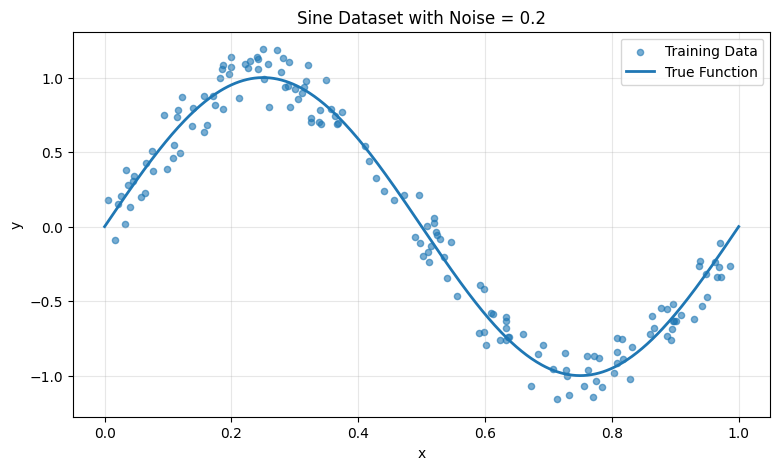

In [64]:
# Step 1: Generate and split the sine dataset
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# True function
def sine_function(x):
    return np.sin(2 * np.pi * x)

# Generate 200 observations with uniform noise [-0.2, 0.2]
np.random.seed(42)

x = np.random.uniform(0, 1, 200)
noise = np.random.uniform(-0.2, 0.2, 200)
y = sine_function(x) + noise

# Dataset format: [x, y]
sine_data = np.column_stack((x, y))

# Fixed 80/20 split
sine_train, sine_test = train_test_split(
    sine_data,
    test_size=0.2,
    random_state=42
)

# Verify dataset dimensions
print("Total dataset:", sine_data.shape)
print("Training dataset:", sine_train.shape)
print("Testing dataset:", sine_test.shape)

# Verify the generated data
assert sine_data.shape == (200, 2)
assert sine_train.shape == (160, 2)
assert sine_test.shape == (40, 2)

print("\nDataset generated and split successfully.")

# Plot training observations and the true function
x_grid = np.linspace(0, 1, 500)

plt.figure(figsize=(9, 5))

plt.scatter(
    sine_train[:, 0],
    sine_train[:, 1],
    alpha=0.6,
    s=20,
    label="Training Data"
)

plt.plot(
    x_grid,
    sine_function(x_grid),
    linewidth=2,
    label="True Function"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Sine Dataset with Noise = 0.2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Ans 11 - Step 2: Train Regression Trees and calculate RMSE

In [65]:

# Ans 11 - Step 2: Train regression trees and calculate RMSE

import numpy as np
import pandas as pd

min_records_values = [2, 4, 8, 16, 32, 64, 128, 256]

results_q11 = []

for min_records in min_records_values:

    # Initialize and train the custom regression tree
    model = RegressionTree()
    model.fit(sine_train, min_records=min_records)

    # Separate input features and target values
    X_train = sine_train[:, :-1]
    y_train = sine_train[:, -1]

    X_test = sine_test[:, :-1]
    y_test = sine_test[:, -1]

    # Generate predictions
    train_pred = np.asarray(model.predict(X_train)).ravel()
    test_pred = np.asarray(model.predict(X_test)).ravel()

    # Calculate RMSE
    train_rmse = np.sqrt(np.mean((y_train - train_pred) ** 2))
    test_rmse = np.sqrt(np.mean((y_test - test_pred) ** 2))

    results_q11.append({
        "min_records": min_records,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

results_q11_df = pd.DataFrame(results_q11)

print("Regression Tree Training and Testing Results")
display(results_q11_df)

assert len(results_q11_df) == 8
assert results_q11_df[["Train RMSE", "Test RMSE"]].notna().all().all()

print("\nAll 8 regression tree configurations completed.")


Regression Tree Training and Testing Results


,min_records,Train RMSE,Test RMSE
0,2,0.000000,0.128482
1,4,0.061473,0.123206
2,8,0.088289,0.131056
3,16,0.105839,0.151068
4,32,0.126431,0.173565
5,64,0.217513,0.262825
6,128,0.330429,0.305235
7,256,0.727508,0.737250



All 8 regression tree configurations completed.


### Ans 11: Step 3 - Plot Training and Testing RMSE

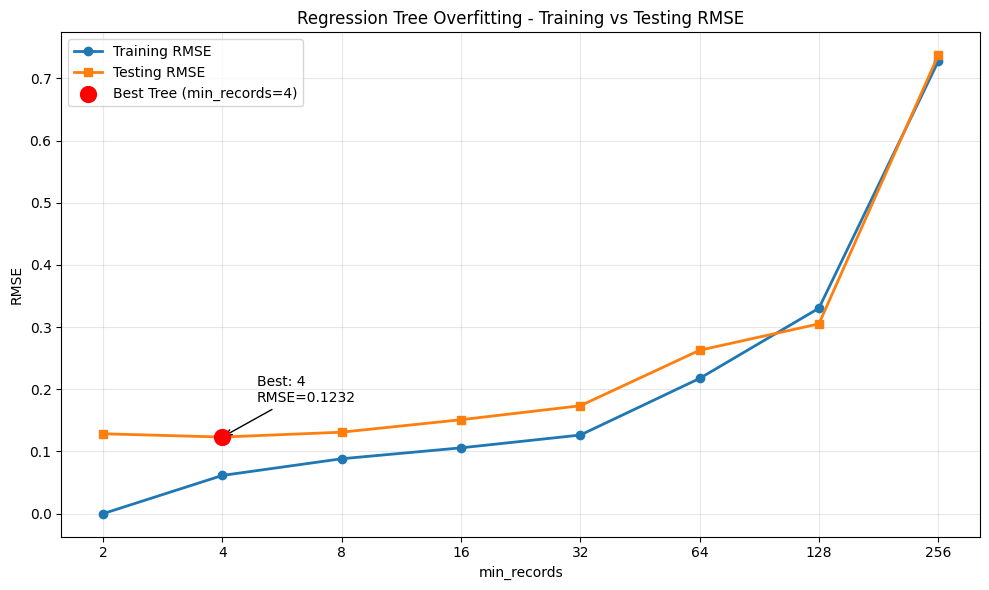

Best min_records: 4
Lowest testing RMSE: 0.123206


In [66]:

# Q11 - Step 3: Plot Training and Testing RMSE

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    results_q11_df["min_records"],
    results_q11_df["Train RMSE"],
    marker="o",
    linewidth=2,
    label="Training RMSE"
)

plt.plot(
    results_q11_df["min_records"],
    results_q11_df["Test RMSE"],
    marker="s",
    linewidth=2,
    label="Testing RMSE"
)

# Identify the best tree using minimum testing RMSE
best_idx = results_q11_df["Test RMSE"].idxmin()
best_min_records = results_q11_df.loc[best_idx, "min_records"]
best_test_rmse = results_q11_df.loc[best_idx, "Test RMSE"]

plt.scatter(
    best_min_records,
    best_test_rmse,
    color="red",
    s=130,
    zorder=5,
    label=f"Best Tree (min_records={int(best_min_records)})"
)

plt.annotate(
    f"Best: {int(best_min_records)}\nRMSE={best_test_rmse:.4f}",
    xy=(best_min_records, best_test_rmse),
    xytext=(25, 25),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)
plt.xscale("log", base=2)
plt.xticks(
    min_records_values,
    [str(value) for value in min_records_values]
)

plt.xlabel("min_records")
plt.ylabel("RMSE")
plt.title("Regression Tree Overfitting - Training vs Testing RMSE")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Best min_records:", int(best_min_records))
print("Lowest testing RMSE:", round(best_test_rmse, 6))


### Answer 11: Regression Tree Overfitting Analysis

**Experimental Setup**

A dataset of 200 observations was generated using the true function $f(x) = \sin(2\pi x)$ with uniformly distributed noise between -0.2 and 0.2. The dataset was divided into 160 training and 40 testing observations. Eight regression trees were trained using `min_records` values of 2, 4, 8, 16, 32, 64, 128, and 256.

**Results and Observations**

1. **Best Model:** The regression tree with `min_records = 4` achieved the lowest testing RMSE of **0.123206** and was selected as the best model among the eight configurations.

2. **Highest Bias:** The tree with `min_records = 256` has the highest expected bias because it cannot split the 160 training observations. It underfits the sine function, producing a training RMSE of 0.727508 and testing RMSE of 0.737250.

3. **Highest Variance:** The tree with `min_records = 2` has the highest expected variance because it fits the training observations most closely, achieving zero training RMSE. Its testing RMSE of 0.128482 is higher than that of the selected model, suggesting overfitting.

**Conclusion**

The experiment demonstrates the bias-variance tradeoff in regression trees. Very small `min_records` values produce highly flexible trees that may overfit, while very large values produce simpler trees that underfit. Based on the lowest observed testing RMSE, **`min_records = 4` is the best configuration** for this experiment.


### Answer 12: Hyperparameters Supported by the Implemented Algorithms

#### 1. Linear Regression

The implemented linear regression algorithm uses the **Normal Equation** to calculate regression coefficients directly. Its `fit()` function does not support explicit training hyperparameters such as learning rate, number of iterations, or regularization strength.

However, the **polynomial degree** can be varied during feature construction to control model complexity, as demonstrated in Question 7 using degrees 1 through 10.

#### 2. Regression Tree

The implemented regression tree supports one explicit hyperparameter, **`min_records`**, with a default value of **2**.

This parameter controls the stopping condition for tree splitting:

- **Smaller `min_records` values:** Allow more splits, producing more complex trees that may overfit.
- **Larger `min_records` values:** Restrict splitting, producing simpler trees that may underfit.

The effect of this parameter was demonstrated experimentally in Questions 9 and 11.

#### Conclusion

The linear regression fitting algorithm has **no explicit training hyperparameters**, while the regression tree supports **`min_records`** to control tree growth. Polynomial degree is a configurable feature-engineering choice for linear regression rather than a hyperparameter of its fitting algorithm.
